# INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 01

## Development of Two Traditional Machine-Learning Intelligent Systems

### Case Study A: Diabetes Prediction

### Case Study B: Vietnam House Price Prediction

Bài thực hành xây dựng hai hệ thống thông minh dựa trên dữ liệu có cấu trúc và các mô hình học máy truyền thống. Cả hai hệ thống được phát triển theo cùng một tiến trình:

`Real-world problem → Data → Feature representation → Preprocessing → Learning model → Prediction → Application`

Case Study A giải quyết bài toán phân loại nguy cơ tiểu đường, trong khi Case Study B giải quyết bài toán hồi quy giá nhà tại Việt Nam. Mỗi hệ thống sử dụng một biểu diễn đầu vào gồm sáu đặc trưng, được đánh giá qua baseline, năm mô hình học máy, ba thí nghiệm có kiểm soát và một mô hình cuối cùng. Kết quả của hai mô hình được triển khai thông qua một application layer dùng chung. Hai trained pipelines được phục vụ bởi Flask backend/REST API; một Web Application và một Android Mobile Application là hai client độc lập sử dụng cùng prediction API. Đồng thời, mỗi miền dữ liệu được bổ sung một biểu diễn Knowledge Graph nhằm minh họa sự khác biệt giữa biểu diễn vector đặc trưng và biểu diễn tri thức dạng đồ thị.


In [1]:
# Standard library: file system, environment, JSON metadata, warnings
import os
import sys
import json
import shutil
import warnings
from pathlib import Path

# Data processing and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utilities for model cloning and data splitting / cross-validation
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_validate,
    cross_val_score,
)

# Preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Baseline models
from sklearn.dummy import DummyClassifier, DummyRegressor

# Classification and regression models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.svm import SVC

# Evaluation metrics for classification and regression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    make_scorer,
)

# Save and load trained pipelines/models
import joblib

# Knowledge Graph database connection
from neo4j import GraphDatabase

# Keep notebook outputs cleaner
warnings.filterwarnings("ignore")

# Fixed random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Pandas display configuration
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


# Record main environment versions for reproducibility
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

import sklearn

print("Scikit-learn:", sklearn.__version__)

Python: 3.14.6
NumPy: 2.4.6
Pandas: 3.0.3
Scikit-learn: 1.9.0


In [2]:
def resolve_data_file(filename):
    """
    Locate a dataset in common notebook locations and return its absolute path.
    """
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
    ]

    for p in candidates:
        if p.exists():
            return p.resolve()

    raise FileNotFoundError(
        f"Không tìm thấy {filename}. Hãy đặt file cùng thư mục notebook."
    )


def rmse(y_true, y_pred):
    """
    Compute Root Mean Squared Error for regression.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def classification_metrics(y_true, y_pred):
    """
    Return the main classification metrics required by the assignment.
    """
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


def regression_metrics(y_true, y_pred):
    """
    Return the five regression metrics used for house-price evaluation.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }


def plot_single_distribution(series, title, xlabel, bins=30):
    """
    Plot a single histogram used in exploratory data analysis.
    """
    # Missing values are ignored only for visualization
    values = pd.Series(series).dropna()

    plt.figure(figsize=(8, 4.5))
    plt.hist(values, bins=bins, edgecolor="black", alpha=0.8)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.25)
    plt.show()


def plot_metric_bar(df, metric, higher_is_better=True):
    """
    Plot model comparison for one evaluation metric.
    """
    # Sort in the correct direction:
    # higher is better for Accuracy/F1/R2,
    # lower is better for MAE/MSE/RMSE/MAPE.
    ordered = df.sort_values(
        metric,
        ascending=not higher_is_better,
    )

    plt.figure(figsize=(9, 4.5))
    plt.bar(ordered["Model"], ordered[metric])
    plt.title(f"Model comparison — {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def draw_simple_kg(nodes, edges, positions, title):
    """
    Draw a small conceptual Knowledge Graph using Matplotlib.

    nodes:
        dictionary mapping node id -> display label

    edges:
        list of (source, relation, destination)

    positions:
        dictionary mapping node id -> (x, y)
    """
    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    # Draw graph nodes
    for node, label in nodes.items():
        x, y = positions[node]

        ax.scatter(
            [x],
            [y],
            s=1800,
            zorder=3,
        )

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=9,
            zorder=4,
        )

    # Draw directed relationships between nodes
    for src, rel, dst in edges:
        x1, y1 = positions[src]
        x2, y2 = positions[dst]

        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->",
                lw=1.5,
            ),
            zorder=2,
        )

        # Place the relationship label near the middle of the edge
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + 0.05,
            rel,
            fontsize=8,
            ha="center",
        )

    ax.set_title(title)
    ax.axis("off")
    plt.show()


# Directory for trained model pipelines and their metadata
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Helpers ready.")

Helpers ready.


# PART A — DIABETES PREDICTION

## 1. System and Problem Definition

Bài toán thứ nhất xây dựng một hệ thống dự đoán `Outcome` từ các chỉ số sức khỏe có cấu trúc. `Outcome` nhận hai giá trị `0` và `1`, vì vậy đây là một bài toán **binary classification**.

**Formal problem statement:**

> Given a six-feature vector describing a previously unseen subject, predict the binary diabetes outcome class and provide a model-estimated probability for the positive class.

Hệ thống nhận sáu giá trị đầu vào, chuyển chúng thành một vector đặc trưng sáu chiều, áp dụng đúng quy trình tiền xử lý đã được học trên dữ liệu huấn luyện và sử dụng một bộ phân loại học máy truyền thống để sinh ra lớp dự đoán. Với các mô hình hỗ trợ xác suất, hệ thống đồng thời trả về xác suất của lớp dương. Đầu ra này chỉ mang ý nghĩa dự đoán học máy trên bộ dữ liệu nghiên cứu và không được xem là chẩn đoán y khoa.


## 2. Intelligent System Diagram

```text
User / Environment
        │
        ▼
Web Application / Android Mobile Application
        │
        ▼
Six health measurements
        │
        ▼
Flask REST API
        │
        ▼
Feature vector x ∈ R^6
        │
        ▼
Imputation + Scaling when required
        │
        ▼
Traditional ML Classifier
        │
        ▼
Class prediction + probability
        │
        ▼
Web / Mobile Result
```


## 3. Dataset Source

Bộ dữ liệu sử dụng trong nghiên cứu là `diabetes.csv`, thuộc nhóm dữ liệu **Pima Indians Diabetes Database**. Nguồn tham khảo của bộ dữ liệu:

`https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database`

Toàn bộ phân tích, thí nghiệm và đánh giá trong Case Study A sử dụng trực tiếp file dữ liệu này.


In [3]:
DIABETES_PATH = resolve_data_file("diabetes.csv")
diabetes_raw = pd.read_csv(DIABETES_PATH)
print("Dataset path:", DIABETES_PATH)
print("Shape:", diabetes_raw.shape)
display(diabetes_raw.head())

Dataset path: C:\DATA\assign\diabetes.csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0000,35,169.5000,33.6000,0.6270,50,1
1,1,85,66.0000,29,102.5000,26.6000,0.3510,31,0
2,8,183,64.0000,32,169.5000,23.3000,0.6720,32,1
3,1,89,66.0000,23,94.0000,28.1000,0.1670,21,0
4,0,137,40.0000,35,168.0000,43.1000,2.2880,33,1


## 4. Dataset Description

Mỗi dòng dữ liệu biểu diễn một đối tượng quan sát. Biến đích `Outcome` biểu diễn lớp cần dự đoán, trong khi các cột còn lại chứa các phép đo số liên quan đến đối tượng. Phân tích mô tả tập trung vào số lượng quan sát, kiểu dữ liệu, giá trị thiếu, các giá trị bằng `0` có khả năng không hợp lệ về mặt đo lường và các thống kê mô tả cơ bản.


In [4]:
print("Rows:", len(diabetes_raw))
print("Columns:", diabetes_raw.shape[1])
display(diabetes_raw.dtypes.to_frame("dtype"))
display(diabetes_raw.isna().sum().to_frame("missing_count"))
display((diabetes_raw == 0).sum().to_frame("zero_count"))
display(diabetes_raw.describe().T)

Rows: 768
Columns: 9


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,float64
SkinThickness,int64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


,missing_count
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


,zero_count
Pregnancies,111
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0000,3.8451,3.3696,0.0000,1.0000,3.0000,6.0000,17.0000
Glucose,768.0000,121.6771,30.4642,44.0000,99.7500,117.0000,140.2500,199.0000
BloodPressure,768.0000,72.3893,12.1060,24.0000,64.0000,72.0000,80.0000,122.0000
SkinThickness,768.0000,29.0898,8.8908,7.0000,25.0000,28.0000,32.0000,99.0000
Insulin,768.0000,141.7539,89.1008,14.0000,102.5000,102.5000,169.5000,846.0000
BMI,768.0000,32.4346,6.8805,18.2000,27.5000,32.0500,36.6000,67.1000
DiabetesPedigreeFunction,768.0000,0.4719,0.3313,0.0780,0.2437,0.3725,0.6262,2.4200
Age,768.0000,33.2409,11.7602,21.0000,24.0000,29.0000,41.0000,81.0000
Outcome,768.0000,0.3490,0.4770,0.0000,0.0000,0.0000,1.0000,1.0000


## 5. Data Representation

Biểu diễn đầu vào chính của hệ thống gồm sáu đặc trưng:

\[
x=[Glucose, BMI, Age, Pregnancies, BloodPressure, DiabetesPedigreeFunction]
\]

| Feature                  | Type      | Model representation              | Meaning                  |
| ------------------------ | --------- | --------------------------------- | ------------------------ |
| Glucose                  | Numerical | imputed + optionally standardized | glucose concentration    |
| BMI                      | Numerical | imputed + optionally standardized | body mass index          |
| Age                      | Numerical | optionally standardized           | age                      |
| Pregnancies              | Numerical | optionally standardized           | number of pregnancies    |
| BloodPressure            | Numerical | imputed + optionally standardized | diastolic blood pressure |
| DiabetesPedigreeFunction | Numerical | optionally standardized           | diabetes pedigree score  |

Biểu diễn đầu vào được phân biệt thành ba mức: dữ liệu thô, dữ liệu sau tiền xử lý và dữ liệu thực sự được mô hình tiếp nhận. Các mô hình nhạy với khoảng cách hoặc độ lớn của đặc trưng như Logistic Regression, KNN và SVM sử dụng standardization; Decision Tree và Random Forest chỉ cần bước imputation.


In [5]:
DIABETES_FEATURES = [
    "Glucose",
    "BMI",
    "Age",
    "Pregnancies",
    "BloodPressure",
    "DiabetesPedigreeFunction",
]
DIABETES_TARGET = "Outcome"
assert set(DIABETES_FEATURES + [DIABETES_TARGET]).issubset(diabetes_raw.columns)

diabetes = diabetes_raw.copy()
# Canonical raw Pima data may contain physiologically invalid zeros. If the supplied file is already cleaned, this has no effect.
for col in ["Glucose", "BloodPressure", "BMI"]:
    diabetes[col] = diabetes[col].replace(0, np.nan)

display(diabetes[DIABETES_FEATURES].isna().sum().to_frame("missing_count_after_check"))

,missing_count_after_check
Glucose,0
BMI,0
Age,0
Pregnancies,0
BloodPressure,0
DiabetesPedigreeFunction,0


## 6. Feature and Target Analysis

Biến đích là một biến phân loại nhị phân, do đó bài toán học có dạng:

$$
\hat{y}=f_\theta(x),\quad x\in\mathbb{R}^6,\quad \hat{y}\in\{0,1\}
$$

Phân bố lớp được khảo sát để xác định mức độ mất cân bằng của dữ liệu. Ma trận tương quan được sử dụng như một phân tích ban đầu về quan hệ tuyến tính giữa các đặc trưng và `Outcome`; kết quả này chỉ mang tính mô tả và không được sử dụng như tiêu chí duy nhất để lựa chọn đặc trưng.


In [6]:
X_diabetes = diabetes[DIABETES_FEATURES].copy()
y_diabetes = diabetes[DIABETES_TARGET].astype(int).copy()

counts = y_diabetes.value_counts().sort_index()
display(
    pd.DataFrame(
        {"count": counts, "percentage": (counts / len(y_diabetes) * 100).round(2)}
    )
)

corr_diabetes = diabetes[DIABETES_FEATURES + [DIABETES_TARGET]].corr(numeric_only=True)
display(corr_diabetes.round(3))

,count,percentage
Outcome,,
0,500,65.1000
1,268,34.9000


,Glucose,BMI,Age,Pregnancies,BloodPressure,DiabetesPedigreeFunction,Outcome
Glucose,1.0000,0.2360,0.2690,0.1300,0.2250,0.1380,0.4960
BMI,0.2360,1.0000,0.0280,0.0240,0.2860,0.1530,0.3160
Age,0.2690,0.0280,1.0000,0.5440,0.3250,0.0340,0.2380
Pregnancies,0.1300,0.0240,0.5440,1.0000,0.2090,-0.0340,0.2220
BloodPressure,0.2250,0.2860,0.3250,0.2090,1.0000,-0.0010,0.1740
DiabetesPedigreeFunction,0.1380,0.1530,0.0340,-0.0340,-0.0010,1.0000,0.1740
Outcome,0.4960,0.3160,0.2380,0.2220,0.1740,0.1740,1.0000


## 7. Exploratory Data Analysis

Phân tích khám phá dữ liệu tập trung vào năm phân bố: `Glucose`, `BMI`, `Age`, `BloodPressure` và `DiabetesPedigreeFunction`. Các histogram cho phép quan sát độ phân tán, độ lệch và các vùng giá trị phổ biến của từng biến. Sau đó, ma trận tương quan được trực quan hóa để mô tả quan hệ tuyến tính giữa các biến số trong representation đang xét.


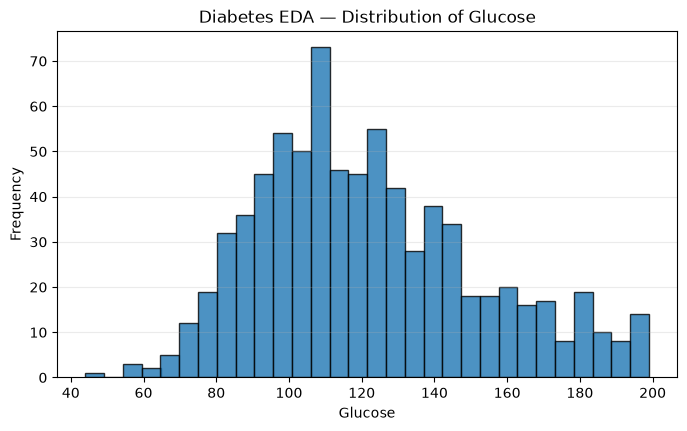

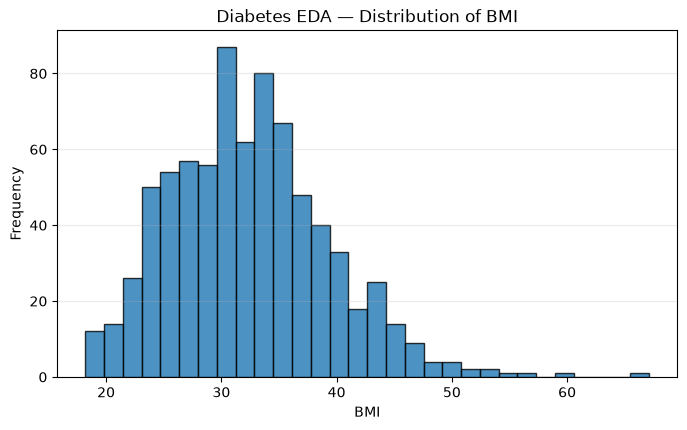

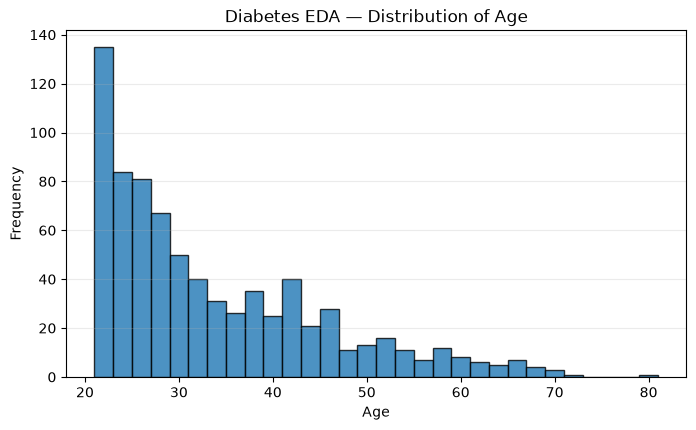

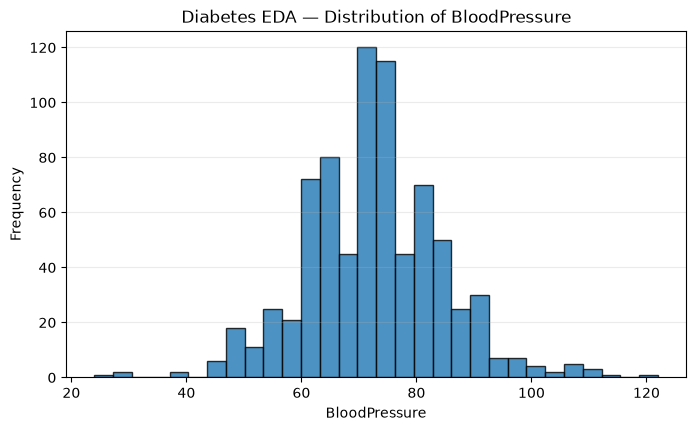

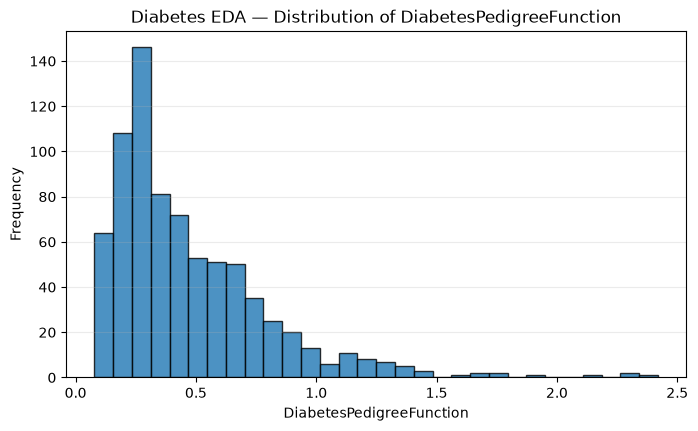

In [7]:
for feature in ["Glucose", "BMI", "Age", "BloodPressure", "DiabetesPedigreeFunction"]:
    plot_single_distribution(
        diabetes[feature], f"Diabetes EDA — Distribution of {feature}", feature, bins=30
    )

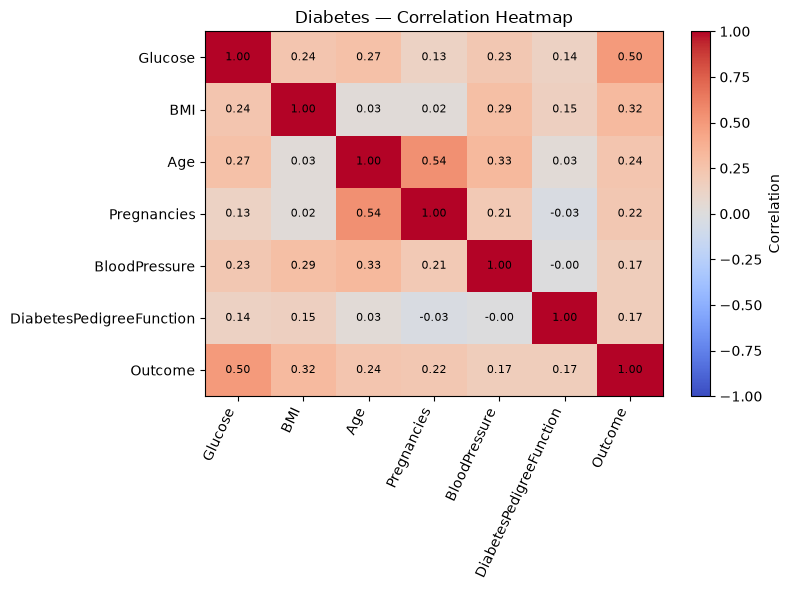

In [8]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_diabetes, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(corr_diabetes.columns)), corr_diabetes.columns, rotation=65, ha="right"
)
plt.yticks(range(len(corr_diabetes.columns)), corr_diabetes.columns)
for i in range(len(corr_diabetes.columns)):
    for j in range(len(corr_diabetes.columns)):
        plt.text(
            j, i, f"{corr_diabetes.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8
        )
plt.title("Diabetes — Correlation Heatmap")
plt.tight_layout()
plt.show()

### Interpretation of Exploratory Data Analysis

**Distribution plots.**  
Các biểu đồ cho thấy năm features có hình dạng phân bố khá khác nhau. `Glucose` tập trung nhiều nhất khoảng 90–140 và có đuôi kéo tới gần 200. `BMI` tập trung chủ yếu quanh 25–40 nhưng lệch phải, với một số observation trên 50. `Age` lệch phải rất rõ: phần lớn observation nằm ở nhóm tuổi khoảng 20–35, sau đó tần suất giảm dần và chỉ còn rất ít trường hợp trên 60 tuổi. `BloodPressure` tập trung mạnh quanh khoảng 60–85 và có một số giá trị thấp hoặc cao nằm xa vùng trung tâm. `DiabetesPedigreeFunction` cũng lệch phải mạnh: phần lớn giá trị nhỏ hơn khoảng 0.8 nhưng có một đuôi dài tới trên 2.

Như vậy dataset không có một dạng phân bố chung cho tất cả features. Đặc biệt, `Age` và `DiabetesPedigreeFunction` có long tail, trong khi `BloodPressure` tập trung hơn quanh vùng trung tâm. Điều này ủng hộ việc đặt preprocessing trong pipeline thay vì giả định các features có cùng scale hoặc cùng phân bố.

**Correlation heatmap.**  
Trong các feature đang dùng, `Glucose` có tương quan tuyến tính với `Outcome` lớn nhất, khoảng **0.50**. Tiếp theo là `BMI` khoảng **0.32**, `Age` khoảng **0.24**, `Pregnancies` khoảng **0.22**, còn `BloodPressure` và `DiabetesPedigreeFunction` đều chỉ khoảng **0.17**. Điều này cho thấy `Glucose` là tín hiệu tuyến tính nổi bật nhất đối với target trong representation hiện tại.

Heatmap cũng cho thấy một số features tương quan với nhau, đáng chú ý nhất là `Age` và `Pregnancies` khoảng **0.54**. Tuy nhiên không có cặp feature nào trong representation đạt tương quan gần tuyệt đối, vì vậy không có dấu hiệu hai biến đơn giản chỉ là bản sao tuyến tính của nhau.

Kết hợp histogram và heatmap, có thể thấy dataset chứa cả sự khác biệt về phân bố lẫn mức độ liên hệ với target. Đây cũng là lý do việc đánh giá representation bằng cross-validation vẫn cần thiết thay vì chỉ chọn feature dựa vào correlation.


## 8. Train/Test Split

Dữ liệu được chia theo tỷ lệ 80% huấn luyện và 20% kiểm thử. Tham số `stratify=y` duy trì tỷ lệ hai lớp giữa hai tập. Tập kiểm thử không tham gia vào quá trình lựa chọn thuật toán, lựa chọn representation hoặc khảo sát siêu tham số; tập này chỉ được sử dụng cho đánh giá cuối cùng.


In [9]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes, test_size=0.20, random_state=SEED, stratify=y_diabetes
)
print("Training shape:", X_train_d.shape)
print("Test shape:", X_test_d.shape)
print("Train positive rate:", round(y_train_d.mean(), 4))
print("Test positive rate:", round(y_test_d.mean(), 4))

Training shape: (614, 6)
Test shape: (154, 6)
Train positive rate: 0.3485
Test positive rate: 0.3506


## 9. Baseline

`DummyClassifier(strategy="most_frequent")` được sử dụng làm baseline. Mô hình này luôn dự đoán lớp phổ biến nhất và không học quan hệ giữa các đặc trưng với biến đích. Vì vậy, baseline cung cấp một mốc tham chiếu tối thiểu để xác định liệu các mô hình học máy có tạo ra giá trị dự đoán vượt quá một chiến lược đơn giản hay không.


In [10]:
diabetes_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
classification_scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}
baseline_d = DummyClassifier(strategy="most_frequent")
s = cross_validate(
    baseline_d,
    X_train_d,
    y_train_d,
    cv=diabetes_cv,
    scoring=classification_scoring,
    n_jobs=1,
)
baseline_d_result = {
    "Accuracy": s["test_accuracy"].mean(),
    "Precision": s["test_precision"].mean(),
    "Recall": s["test_recall"].mean(),
    "F1": s["test_f1"].mean(),
}
display(pd.DataFrame([baseline_d_result], index=["DummyClassifier"]).round(4))

,Accuracy,Precision,Recall,F1
DummyClassifier,0.6515,0.0000,0.0000,0.0000


## 10–14. Traditional Machine-Learning Models

Năm thuật toán được xây dựng trên cùng một representation sáu chiều. Tiền xử lý được đặt bên trong `Pipeline`, nhờ đó các thống kê imputation và scaling luôn được ước lượng chỉ từ phần dữ liệu huấn luyện tương ứng trong từng fold.

| Model               | Input representation | Learned relationship              | Learned structure        | Main criterion           | Strength                    | Limitation                               |
| ------------------- | -------------------- | --------------------------------- | ------------------------ | ------------------------ | --------------------------- | ---------------------------------------- |
| Logistic Regression | standardized 6D      | linear log-odds boundary          | weights + bias           | log-loss                 | interpretable and stable    | limited nonlinear modeling               |
| KNN                 | standardized 6D      | local neighborhood                | stored training examples | distance + voting        | simple nonlinear model      | sensitive to scaling and k               |
| Decision Tree       | imputed 6D           | recursive decision rules          | split thresholds         | impurity reduction       | interpretable rules         | overfitting risk                         |
| Random Forest       | imputed 6D           | ensemble nonlinear rules          | multiple decision trees  | aggregated tree learning | robust nonlinear model      | lower interpretability                   |
| SVM (RBF)           | standardized 6D      | nonlinear maximum-margin boundary | support vectors + kernel | margin objective         | flexible nonlinear boundary | sensitive to scaling and hyperparameters |


In [11]:
diabetes_models = {
    "Logistic Regression": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
        ]
    ),
    "KNN": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=15)),
        ]
    ),
    "Decision Tree": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(max_depth=5, random_state=SEED)),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=1),
            ),
        ]
    ),
    "SVM (RBF)": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=1.0, probability=True, random_state=SEED)),
        ]
    ),
}
print(list(diabetes_models))

['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM (RBF)']


## 15. Evaluation

Các mô hình phân loại được đánh giá bằng bốn độ đo định lượng: **Accuracy, Precision, Recall và F1-score**. Ngoài bảng so sánh, kết quả được trực quan hóa bằng các biểu đồ tương ứng. Confusion Matrix được sử dụng cho mô hình cuối cùng để mô tả chi tiết số lượng true positive, true negative, false positive và false negative. ROC curve và ROC-AUC được bổ sung để quan sát khả năng phân biệt hai lớp theo nhiều ngưỡng dự đoán khác nhau.

Việc so sánh năm mô hình ở giai đoạn này sử dụng 5-fold cross-validation trên tập huấn luyện.


In [12]:
rows = []
for name, model in diabetes_models.items():
    s = cross_validate(
        model,
        X_train_d,
        y_train_d,
        cv=diabetes_cv,
        scoring=classification_scoring,
        n_jobs=1,
    )
    rows.append(
        {
            "Model": name,
            "Accuracy": s["test_accuracy"].mean(),
            "Precision": s["test_precision"].mean(),
            "Recall": s["test_recall"].mean(),
            "F1": s["test_f1"].mean(),
        }
    )
diabetes_cv_results = (
    pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
)
display(diabetes_cv_results.round(4))

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.7899,0.7597,0.5889,0.6618
1,SVM (RBF),0.7785,0.7469,0.5703,0.6417
2,Random Forest,0.7654,0.7022,0.5888,0.6376
3,KNN,0.7508,0.6985,0.5426,0.6022
4,Decision Tree,0.7166,0.6202,0.4903,0.5447


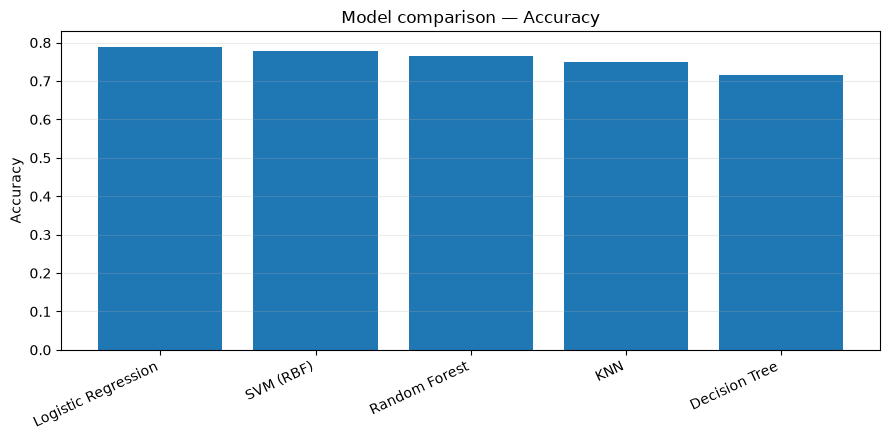

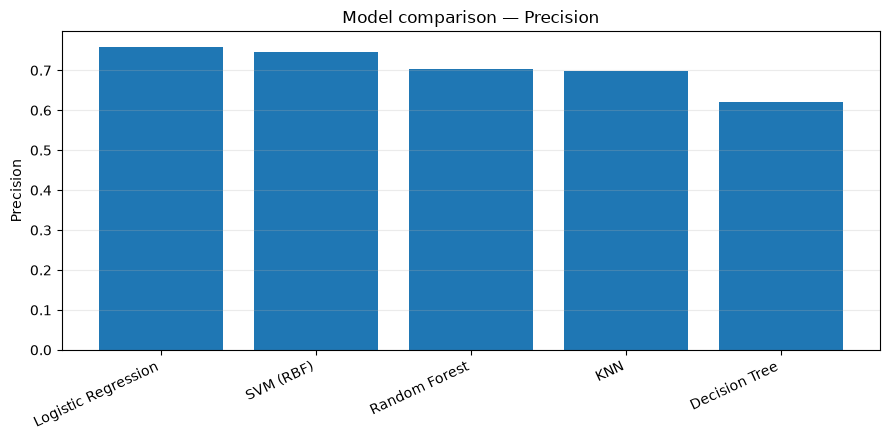

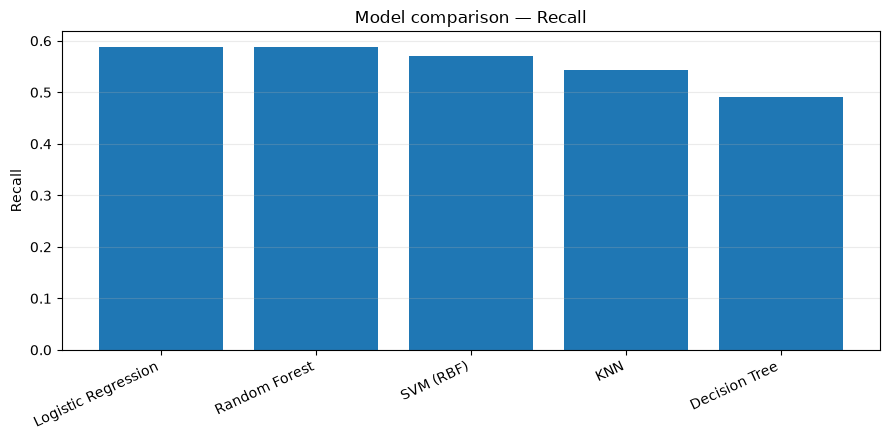

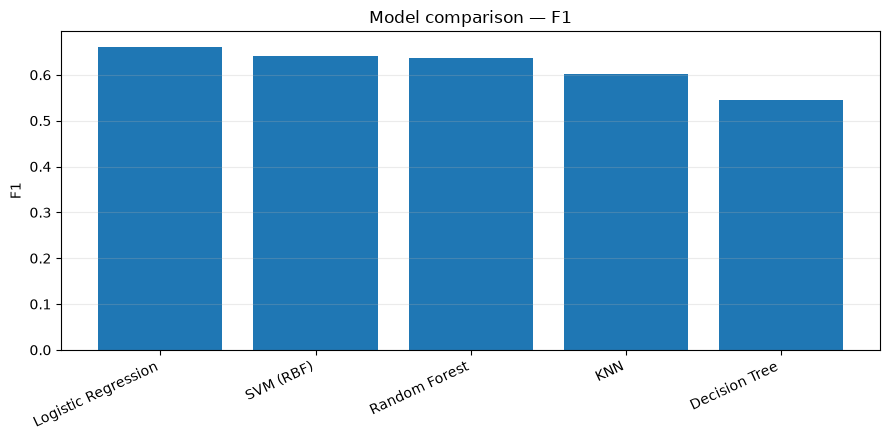

In [13]:
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    plot_metric_bar(diabetes_cv_results, metric, higher_is_better=True)

### Interpretation of Model Evaluation Plots

Bốn biểu đồ cho thấy **Logistic Regression là model ổn định nhất trong nhóm năm classifier**. Nó đạt Accuracy **0.7899**, Precision **0.7597** và F1 **0.6618**, đều cao nhất trong bảng cross-validation. Recall của Logistic Regression là **0.5889**, gần như ngang Random Forest (**0.5888**) và nhỉnh hơn SVM (**0.5703**).

SVM đứng thứ hai về Accuracy, Precision và F1 với F1 **0.6417**. Random Forest có Recall gần bằng Logistic Regression nhưng Precision thấp hơn đáng kể (**0.7022** so với **0.7597**), nên F1 chỉ còn **0.6376**. KNN thấp hơn nhóm ba model trên, còn Decision Tree đứng cuối ở cả Accuracy (**0.7166**), Precision (**0.6202**), Recall (**0.4903**) và F1 (**0.5447**).

Một pattern quan trọng là **Precision của tất cả model đều cao hơn Recall**. Ngay cả model tốt nhất cũng chỉ có Recall khoảng **0.59**, nghĩa là khả năng phát hiện lớp positive vẫn là điểm yếu hơn so với khả năng tránh false positive. Vì tiêu chí lựa chọn đã đặt trước là mean CV F1, Logistic Regression được chọn hợp lý: nó tạo cân bằng Precision–Recall tốt nhất trong các model được thử, chứ không chỉ thắng ở Accuracy.


## 16. Experiment 1 — Model Comparison

Thí nghiệm thứ nhất trả lời câu hỏi: **trong cùng một representation sáu đặc trưng, cùng quy trình tiền xử lý và cùng 5-fold cross-validation, mô hình nào đạt F1-score trung bình cao nhất?**

Training set, tập đặc trưng, số fold và random seed được giữ cố định; biến độc lập duy nhất là thuật toán học máy. Thiết kế này cho phép quy khác biệt về kết quả chủ yếu cho lựa chọn mô hình.


In [14]:
best_diabetes_model_name = diabetes_cv_results.iloc[0]["Model"]
best_diabetes_cv_f1 = float(diabetes_cv_results.iloc[0]["F1"])
print("Best model by mean CV F1:", best_diabetes_model_name)
print("Mean CV F1:", round(best_diabetes_cv_f1, 4))

Best model by mean CV F1: Logistic Regression
Mean CV F1: 0.6618


## 17. Experiment 2 — Hyperparameter Investigation

Thí nghiệm thứ hai khảo sát ảnh hưởng của tham số `n_neighbors = k` đối với KNN. Representation, imputation, standardization và cross-validation protocol được giữ nguyên, trong khi `k` lần lượt nhận nhiều giá trị khác nhau. F1-score trung bình qua các fold được sử dụng để đánh giá ảnh hưởng của kích thước lân cận đến khả năng phân loại.


,k,Mean CV F1
0,3,0.6099
1,5,0.6203
2,7,0.5905
3,9,0.5987
4,11,0.6000
5,15,0.6022
6,19,0.6146
7,25,0.6250


Best k: 25


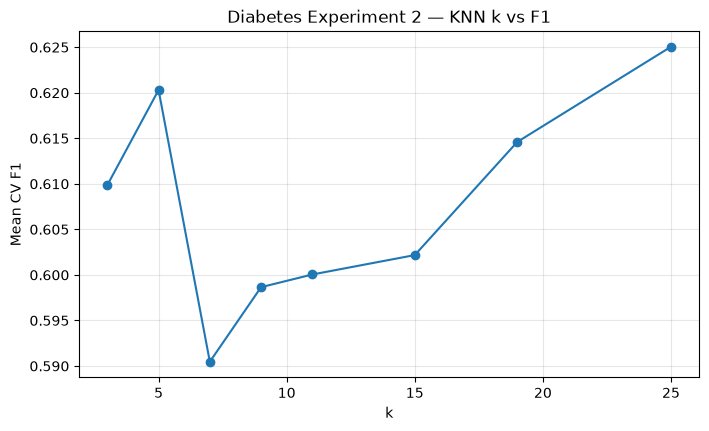

In [15]:
k_values = [3, 5, 7, 9, 11, 15, 19, 25]
knn_scores = []
for k in k_values:
    p = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    s = cross_val_score(
        p,
        X_train_d,
        y_train_d,
        cv=diabetes_cv,
        scoring=make_scorer(f1_score, zero_division=0),
        n_jobs=1,
    )
    knn_scores.append(s.mean())
knn_experiment = pd.DataFrame({"k": k_values, "Mean CV F1": knn_scores})
display(knn_experiment.round(4))
best_k = int(knn_experiment.loc[knn_experiment["Mean CV F1"].idxmax(), "k"])
print("Best k:", best_k)
plt.figure(figsize=(8, 4.5))
plt.plot(k_values, knn_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Mean CV F1")
plt.title("Diabetes Experiment 2 — KNN k vs F1")
plt.grid(alpha=0.3)
plt.show()

### Interpretation of KNN Hyperparameter Plot

KNN không cải thiện đều khi `k` tăng. Mean CV F1 tăng từ **0.6099 tại k=3** lên **0.6203 tại k=5**, sau đó giảm mạnh xuống mức thấp nhất **0.5905 tại k=7**. Từ `k=9` trở đi, F1 tăng dần: **0.5987 → 0.6000 → 0.6022 → 0.6146**, và đạt giá trị cao nhất trong các cấu hình đã thử là **0.6250 tại k=25**.

Như vậy hiệu năng của KNN khá nhạy với lựa chọn `k`, đặc biệt ở vùng `k` nhỏ. Trong khoảng đã thử, các giá trị lớn hơn tạo kết quả ổn định hơn sau điểm giảm tại `k=7`. Tuy nhiên ngay cả cấu hình tốt nhất `k=25` vẫn thấp hơn F1 của Logistic Regression (**0.6618**), nên tuning `k` chưa làm KNN trở thành lựa chọn tốt nhất.

Do điểm tốt nhất nằm ngay tại biên trên của tập giá trị đã khảo sát (`k=25`), thí nghiệm chỉ cho phép kết luận rằng **25 là tốt nhất trong các giá trị đã thử**, không phải 25 chắc chắn là giá trị tối ưu toàn cục.


## 18. Experiment 3 — Representation / Feature Investigation

Thí nghiệm thứ ba đánh giá trực tiếp ảnh hưởng của representation. Hai biểu diễn được so sánh:

\[
X_3=[Glucose,BMI,Age]
\]

và

\[
X_6=[Glucose,BMI,Age,Pregnancies,BloodPressure,DiabetesPedigreeFunction]
\]

Cả hai representation sử dụng cùng Logistic Regression pipeline và cùng cross-validation protocol. Vì thuật toán và quy trình đánh giá được giữ cố định, thay đổi về F1-score phản ánh tác động của lượng thông tin được cung cấp cho mô hình.


,Representation,Accuracy,Precision,Recall,F1
0,3 features,0.7850,0.7474,0.5842,0.6550
1,6 features,0.7899,0.7597,0.5889,0.6618


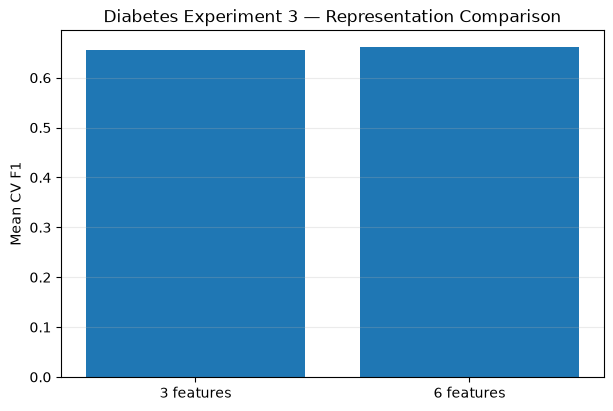

In [16]:
rep_model_d = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
    ]
)
rep_rows = []
for label, fs in {
    "3 features": ["Glucose", "BMI", "Age"],
    "6 features": DIABETES_FEATURES,
}.items():
    Xrep = diabetes.loc[X_train_d.index, fs]
    s = cross_validate(
        rep_model_d,
        Xrep,
        y_train_d,
        cv=diabetes_cv,
        scoring=classification_scoring,
        n_jobs=1,
    )
    rep_rows.append(
        {
            "Representation": label,
            "Accuracy": s["test_accuracy"].mean(),
            "Precision": s["test_precision"].mean(),
            "Recall": s["test_recall"].mean(),
            "F1": s["test_f1"].mean(),
        }
    )
diabetes_representation_results = pd.DataFrame(rep_rows)
display(diabetes_representation_results.round(4))
plt.figure(figsize=(7, 4.5))
plt.bar(
    diabetes_representation_results["Representation"],
    diabetes_representation_results["F1"],
)
plt.ylabel("Mean CV F1")
plt.title("Diabetes Experiment 3 — Representation Comparison")
plt.grid(axis="y", alpha=0.25)
plt.show()

### Interpretation of Representation Comparison

Khi Logistic Regression chỉ dùng ba features `Glucose`, `BMI` và `Age`, mean CV F1 đạt **0.6550**. Khi mở rộng lên đủ sáu features, F1 tăng lên **0.6618**. Accuracy cũng tăng nhẹ từ **0.7850** lên **0.7899**, Precision từ **0.7474** lên **0.7597**, và Recall từ **0.5842** lên **0.5889**.

Như vậy representation sáu chiều **tốt hơn nhưng mức cải thiện khá nhỏ**: F1 chỉ tăng khoảng **0.0068**. Điều này cho thấy ba features bổ sung (`Pregnancies`, `BloodPressure`, `DiabetesPedigreeFunction`) có đóng góp thêm thông tin, nhưng phần lớn predictive signal của representation hiện tại đã nằm trong ba biến `Glucose`, `BMI` và `Age`.

Kết quả này phù hợp với heatmap trước đó: `Glucose` có correlation với `Outcome` cao nhất (**0.50**), `BMI` đứng thứ hai (**0.32**) và `Age` cũng cao hơn phần lớn các feature còn lại. Vì vậy, thêm feature mang lại lợi ích có thật nhưng không tạo ra bước nhảy lớn về hiệu năng.


## 19. Final Model

Mô hình cuối cùng được xác định bằng F1-score trung bình cao nhất trên cross-validation của tập huấn luyện. Sau khi lựa chọn, pipeline tương ứng được huấn luyện lại trên toàn bộ training set và chỉ sau đó mới được đánh giá một lần trên held-out test set. Kết quả cuối cùng được trình bày bằng Accuracy, Precision, Recall, F1-score, Confusion Matrix và ROC-AUC.


In [17]:
final_diabetes_model = clone(diabetes_models[best_diabetes_model_name])
final_diabetes_model.fit(X_train_d, y_train_d)
y_pred_d = final_diabetes_model.predict(X_test_d)
final_diabetes_metrics = classification_metrics(y_test_d, y_pred_d)
print("Final diabetes model:", best_diabetes_model_name)
display(pd.DataFrame([final_diabetes_metrics], index=["Held-out test"]).round(4))

Final diabetes model: Logistic Regression


,Accuracy,Precision,Recall,F1
Held-out test,0.6948,0.5778,0.4815,0.5253


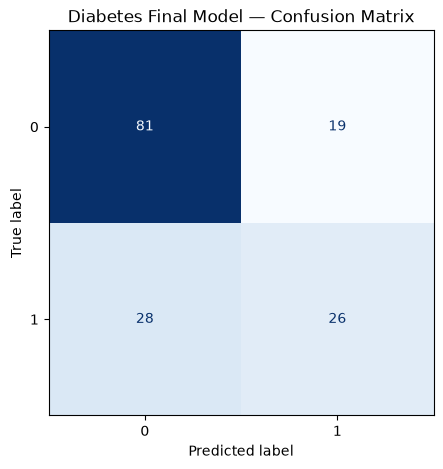

In [18]:
cm = confusion_matrix(y_test_d, y_pred_d)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Diabetes Final Model — Confusion Matrix")
plt.show()

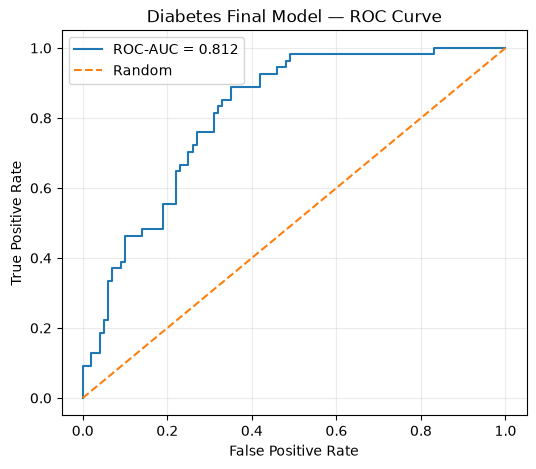

ROC-AUC: 0.8119


In [19]:
if hasattr(final_diabetes_model, "predict_proba"):
    y_prob_d = final_diabetes_model.predict_proba(X_test_d)[:, 1]
    auc_d = roc_auc_score(y_test_d, y_prob_d)
    fpr, tpr, _ = roc_curve(y_test_d, y_prob_d)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_d:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Diabetes Final Model — ROC Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
    print("ROC-AUC:", round(auc_d, 4))

### Interpretation of Final Classification Plots

**Confusion Matrix.**  
Trên held-out test set, model dự đoán đúng **81 trường hợp lớp 0** và **26 trường hợp lớp 1**. Nó tạo **19 false positives** nhưng có tới **28 false negatives**. Với 54 observation thực sự thuộc lớp 1, model chỉ phát hiện đúng 26 trường hợp, tương ứng Recall **0.4815**. Ngược lại, trong 100 observation lớp 0, model nhận đúng 81 trường hợp.

Pattern này cho thấy threshold phân loại hiện tại thiên về việc nhận diện lớp 0 tốt hơn lớp 1. Đáng chú ý, số positive case bị bỏ sót (**28**) còn nhiều hơn số positive case phát hiện đúng (**26**). Điều này giải thích tại sao held-out Accuracy vẫn đạt **0.6948** nhưng F1 chỉ còn **0.5253** và Recall thấp hơn kết quả cross-validation.

**ROC Curve.**  
ROC curve nằm rõ ràng phía trên đường random và ROC-AUC đạt **0.8119**. Điều này cho thấy model vẫn có khả năng **xếp hạng / phân biệt hai lớp khá tốt** khi xét trên nhiều threshold khác nhau, dù confusion matrix tại threshold mặc định cho Recall chưa cao.

Kết hợp hai biểu đồ, vấn đề của final model không phải là hoàn toàn không tách được hai lớp; AUC khoảng 0.812 cho thấy vẫn có signal phân biệt đáng kể. Điểm hạn chế nằm nhiều hơn ở operating threshold hiện tại và ở sự đánh đổi giữa false positive với false negative. Vì Assignment lựa chọn model theo CV F1 và không thực hiện threshold tuning, kết quả này được giữ như đánh giá trung thực của pipeline cuối cùng.


In [ ]:
DIABETES_MODEL_PATH = ARTIFACT_DIR / "diabetes_pipeline.joblib"
DIABETES_MODELS_DIR = ARTIFACT_DIR / "diabetes_models"
DIABETES_MODELS_DIR.mkdir(exist_ok=True)

DIABETES_MODEL_SLUGS = {
    "Logistic Regression": "logistic_regression",
    "KNN": "knn",
    "Decision Tree": "decision_tree",
    "Random Forest": "random_forest",
    "SVM (RBF)": "svm_rbf",
}

# Preserve the existing artifact as the recommended/final model.
joblib.dump(final_diabetes_model, DIABETES_MODEL_PATH)

# Fit one deployable pipeline for each of the five evaluated algorithms.
# The recommended model reuses final_diabetes_model so its artifact is
# exactly the same trained pipeline used for the held-out test evaluation.
diabetes_deployment_models = {}
for model_name, model_template in diabetes_models.items():
    if model_name == best_diabetes_model_name:
        fitted_model = final_diabetes_model
    else:
        fitted_model = clone(model_template)
        fitted_model.fit(X_train_d, y_train_d)

    model_id = DIABETES_MODEL_SLUGS[model_name]
    model_path = DIABETES_MODELS_DIR / f"{model_id}.joblib"
    joblib.dump(fitted_model, model_path)

    diabetes_deployment_models[model_id] = {
        "name": model_name,
        "artifact": str(Path("diabetes_models") / f"{model_id}.joblib"),
        "recommended": model_name == best_diabetes_model_name,
    }

recommended_diabetes_model_id = DIABETES_MODEL_SLUGS[best_diabetes_model_name]

meta = {
    "task": "binary_classification",
    "features": DIABETES_FEATURES,
    "target": DIABETES_TARGET,
    "selected_model": best_diabetes_model_name,
    "recommended_model_id": recommended_diabetes_model_id,
    "selection_metric": "mean_cv_f1",
    "available_models": diabetes_deployment_models,
    "test_metrics": {k: float(v) for k, v in final_diabetes_metrics.items()},
}
(ARTIFACT_DIR / "diabetes_metadata.json").write_text(
    json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("Saved recommended diabetes model:", DIABETES_MODEL_PATH)
print("Saved selectable diabetes models:")
for model_id, info in diabetes_deployment_models.items():
    marker = " <- recommended" if info["recommended"] else ""
    print(f"  {model_id}: {info['artifact']}{marker}")

Saved recommended diabetes model: artifacts\diabetes_pipeline.joblib
Saved selectable diabetes models:
  logistic_regression: diabetes_models\logistic_regression.joblib <- recommended
  knn: diabetes_models\knn.joblib
  decision_tree: diabetes_models\decision_tree.joblib
  random_forest: diabetes_models\random_forest.joblib
  svm_rbf: diabetes_models\svm_rbf.joblib


## 20. Knowledge Graph — Diabetes

Bên cạnh representation dạng vector, miền dữ liệu tiểu đường được mô hình hóa bằng một Knowledge Graph. Đồ thị biểu diễn các thực thể `Subject`, `Feature`, `Prediction`, `MLModel` và `TargetConcept`, cùng các quan hệ `HAS_FEATURE`, `HAS_PREDICTION`, `PREDICTED_BY` và `ABOUT`.

Feature vector phù hợp cho numerical learning, trong khi Knowledge Graph thể hiện rõ cấu trúc ngữ nghĩa giữa các thực thể. Script Cypher được sinh ra để representation này có thể được lưu trong Neo4j.


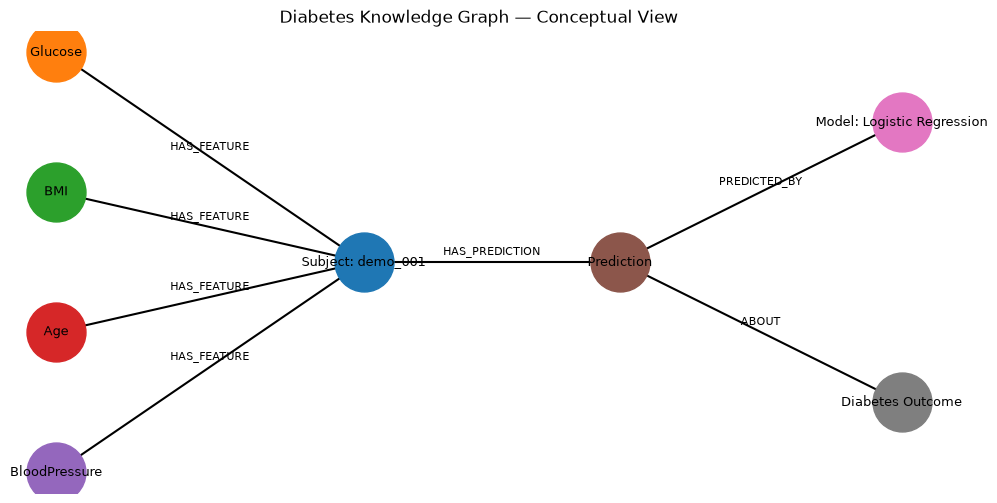

In [21]:
nodes = {
    "subject": "Subject: demo_001",
    "glucose": "Glucose",
    "bmi": "BMI",
    "age": "Age",
    "bp": "BloodPressure",
    "pred": "Prediction",
    "model": f"Model: {best_diabetes_model_name}",
    "target": "Diabetes Outcome",
}
edges = [
    ("subject", "HAS_FEATURE", "glucose"),
    ("subject", "HAS_FEATURE", "bmi"),
    ("subject", "HAS_FEATURE", "age"),
    ("subject", "HAS_FEATURE", "bp"),
    ("subject", "HAS_PREDICTION", "pred"),
    ("pred", "PREDICTED_BY", "model"),
    ("pred", "ABOUT", "target"),
]
pos = {
    "subject": (0, 0),
    "glucose": (-2.4, 1.5),
    "bmi": (-2.4, 0.5),
    "age": (-2.4, -0.5),
    "bp": (-2.4, -1.5),
    "pred": (2, 0),
    "model": (4.2, 1),
    "target": (4.2, -1),
}
draw_simple_kg(nodes, edges, pos, "Diabetes Knowledge Graph — Conceptual View")

In [22]:
NEO4J_DIR = Path("neo4j_scripts")
NEO4J_DIR.mkdir(exist_ok=True)

diabetes_cypher = f"""
MERGE (s:Subject {{id:'demo_001'}})
MERGE (g:Feature {{name:'Glucose'}})
MERGE (b:Feature {{name:'BMI'}})
MERGE (a:Feature {{name:'Age'}})
MERGE (bp:Feature {{name:'BloodPressure'}})
MERGE (t:TargetConcept {{name:'Diabetes Outcome'}})
MERGE (m:MLModel {{name:'{best_diabetes_model_name}'}})
MERGE (p:Prediction {{task:'Diabetes Classification'}})
MERGE (s)-[:HAS_FEATURE]->(g)
MERGE (s)-[:HAS_FEATURE]->(b)
MERGE (s)-[:HAS_FEATURE]->(a)
MERGE (s)-[:HAS_FEATURE]->(bp)
MERGE (s)-[:HAS_PREDICTION]->(p)
MERGE (p)-[:PREDICTED_BY]->(m)
MERGE (p)-[:ABOUT]->(t);
""".strip()

path = NEO4J_DIR / "diabetes_knowledge_graph.cypher"
path.write_text(diabetes_cypher, encoding="utf-8")
print(diabetes_cypher)
print()
print("Saved:", path)

MERGE (s:Subject {id:'demo_001'})
MERGE (g:Feature {name:'Glucose'})
MERGE (b:Feature {name:'BMI'})
MERGE (a:Feature {name:'Age'})
MERGE (bp:Feature {name:'BloodPressure'})
MERGE (t:TargetConcept {name:'Diabetes Outcome'})
MERGE (m:MLModel {name:'Logistic Regression'})
MERGE (p:Prediction {task:'Diabetes Classification'})
MERGE (s)-[:HAS_FEATURE]->(g)
MERGE (s)-[:HAS_FEATURE]->(b)
MERGE (s)-[:HAS_FEATURE]->(a)
MERGE (s)-[:HAS_FEATURE]->(bp)
MERGE (s)-[:HAS_PREDICTION]->(p)
MERGE (p)-[:PREDICTED_BY]->(m)
MERGE (p)-[:ABOUT]->(t);

Saved: neo4j_scripts\diabetes_knowledge_graph.cypher


### Neo4j Integration

Knowledge Graph được lưu dưới dạng Cypher và có thể được đồng bộ với Neo4j khi các biến môi trường `NEO4J_URI`, `NEO4J_USER` và `NEO4J_PASSWORD` tồn tại. Việc không có kết nối Neo4j không ảnh hưởng đến quá trình huấn luyện và đánh giá mô hình; representation đồ thị vẫn được tạo và trực quan hóa trong notebook.


In [23]:
from dotenv import load_dotenv

load_dotenv()


def optional_run_neo4j(cypher_text):
    uri, user, password = (
        os.getenv("NEO4J_URI"),
        os.getenv("NEO4J_USER"),
        os.getenv("NEO4J_PASSWORD"),
    )
    if not all([uri, user, password]):
        print("Neo4j credentials are not configured -> skipped.")
        return
    try:
        from neo4j import GraphDatabase
    except ImportError:
        print("Package 'neo4j' is not installed -> skipped.")
        return
    driver = GraphDatabase.driver(uri, auth=(user, password))
    try:
        with driver.session() as session:
            session.run(cypher_text)
        print("Knowledge Graph uploaded to Neo4j.")
    finally:
        driver.close()


optional_run_neo4j(diabetes_cypher)

Knowledge Graph uploaded to Neo4j.


## 21. Application

Hệ thống triển khai sử dụng đúng sáu trường đầu vào đã được xác định trong representation. Web Application và Android Mobile Application gửi cùng một cấu trúc dữ liệu tới Flask REST API, đồng thời người dùng có thể chọn một trong năm classifier đã được đánh giá trong notebook. Backend chuyển dữ liệu thành một `DataFrame` có cùng tên và thứ tự cột với dữ liệu huấn luyện rồi truyền trực tiếp qua trained pipeline tương ứng với model được chọn.

Notebook vẫn lưu `diabetes_pipeline.joblib` như artifact của final/recommended model, đồng thời lưu thêm năm selectable pipelines trong `artifacts/diabetes_models/`. Vì mỗi artifact chứa cả preprocessing và estimator, logic xử lý ở giai đoạn triển khai nhất quán với logic được sử dụng khi huấn luyện. Backend trả về predicted class và positive-class probability của model được chọn.

Đây là kết quả dự đoán của mô hình học máy phục vụ mục đích học tập, không phải chẩn đoán y khoa.


## 22. System Demonstration

Ba trường hợp đầu vào đại diện cho các vùng giá trị khác nhau được đưa qua toàn bộ pipeline:

`Input → Feature Representation → Preprocessing → Model → Prediction`

Kết quả thu được minh họa khả năng xử lý dữ liệu chưa từng xuất hiện trong tập huấn luyện dưới đúng representation đã định nghĩa.


In [24]:
diabetes_demo_cases = pd.DataFrame(
    [
        {
            "Glucose": 85,
            "BMI": 22.0,
            "Age": 24,
            "Pregnancies": 1,
            "BloodPressure": 68,
            "DiabetesPedigreeFunction": 0.20,
        },
        {
            "Glucose": 125,
            "BMI": 29.5,
            "Age": 38,
            "Pregnancies": 3,
            "BloodPressure": 78,
            "DiabetesPedigreeFunction": 0.55,
        },
        {
            "Glucose": 180,
            "BMI": 36.0,
            "Age": 55,
            "Pregnancies": 6,
            "BloodPressure": 88,
            "DiabetesPedigreeFunction": 0.85,
        },
    ]
)[DIABETES_FEATURES]
r = diabetes_demo_cases.copy()
r["Predicted Outcome"] = final_diabetes_model.predict(diabetes_demo_cases)
if hasattr(final_diabetes_model, "predict_proba"):
    r["Positive-class probability"] = final_diabetes_model.predict_proba(
        diabetes_demo_cases
    )[:, 1]
display(r.round(4))

,Glucose,BMI,Age,Pregnancies,BloodPressure,DiabetesPedigreeFunction,Predicted Outcome,Positive-class probability
0,85,22.0000,24,1,68,0.2000,0,0.0185
1,125,29.5000,38,3,78,0.5500,0,0.2612
2,180,36.0000,55,6,88,0.8500,1,0.9233


## 23. Reflection — Diabetes

Hệ thống tiếp nhận sáu phép đo dạng số và lưu chúng trong một vector đặc trưng sáu chiều. Từ các ví dụ có nhãn trong tập huấn luyện, mô hình học quan hệ thống kê giữa representation này với `Outcome`, sau đó áp dụng quan hệ đã học cho các vector mới để tạo ra class prediction. Khả năng học từ ví dụ và tổng quát hóa sang dữ liệu chưa quan sát là thành phần có thể xem là biểu hiện của “intelligence” trong phạm vi Assignment 01.

Tuy nhiên, trained model không đồng nhất với toàn bộ intelligent system. Hệ thống hoàn chỉnh còn bao gồm bước tiếp nhận dữ liệu, tiền xử lý, biểu diễn, suy luận và hiển thị kết quả. Representation hiện tại chỉ giữ lại sáu thuộc tính có cấu trúc nên làm mất nhiều thông tin như lịch sử sức khỏe theo thời gian, bối cảnh lâm sàng, lối sống và các nguồn dữ liệu khác. Cùng bài toán có thể được biểu diễn dưới dạng sequence, graph hoặc learned embedding nếu có dữ liệu phong phú hơn.

Xét theo tiến trình phát triển của AI, hệ thống này thuộc giai đoạn:

`Structured Data → Human-designed Features → Statistical/Traditional ML → Prediction`.


## 24. Conclusion — Diabetes

Case Study A đã xây dựng một hệ thống phân loại hoàn chỉnh từ dữ liệu có cấu trúc đến ứng dụng dự đoán. Hệ thống sử dụng representation sáu đặc trưng, thiết lập baseline, huấn luyện năm mô hình truyền thống, thực hiện ba thí nghiệm có kiểm soát và lựa chọn final model dựa trên bằng chứng cross-validation. Hiệu năng cuối cùng được đánh giá trên held-out test set bằng nhiều độ đo và trực quan hóa. Representation dạng vector được bổ sung bằng Knowledge Graph và pipeline cuối cùng được lưu để phục vụ chung cho Web Application và Android Mobile Application thông qua REST API.


# PART B — VIETNAM HOUSE PRICE PREDICTION

## 1. System and Problem Definition

Bài toán thứ hai xây dựng hệ thống dự đoán giá nhà từ sáu thuộc tính cấu trúc của một căn nhà. Vì `Price` là biến số liên tục, đây là một bài toán **regression**.

**Formal problem statement:**

> Given a six-feature vector describing a previously unseen house, predict its numerical `Price` value in the same unit used by the dataset.

Hệ thống tiếp nhận sáu thuộc tính của căn nhà từ Web Application hoặc Android Mobile Application, gửi dữ liệu tới Flask REST API, tạo representation sáu chiều, thực hiện tiền xử lý nhất quán với giai đoạn huấn luyện và sử dụng mô hình hồi quy đã lưu để sinh ra giá dự đoán. Web và Mobile là hai client độc lập nhưng sử dụng cùng backend và cùng trained pipeline.


## 2. Intelligent System Diagram

```text
User / Environment
        │
        ▼
Web Application / Android Mobile Application
        │
        ▼
Six house attributes
        │
        ▼
Flask REST API
        │
        ▼
Feature vector x ∈ R^6
        │
        ▼
Median Imputation + Scaling when required
        │
        ▼
Traditional ML Regressor
        │
        ▼
Predicted Price
        │
        ▼
Web / Mobile Result
```


## 3. Dataset Source

Bộ dữ liệu sử dụng là **House Price Prediction Dataset Vietnam - 2024**, được cung cấp trên Kaggle tại:

`https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024`

File dữ liệu được sử dụng trong notebook là `vietnam_housing_dataset.csv`.


In [25]:
HOUSE_PATH = resolve_data_file("vietnam_housing_dataset.csv")
house_raw = pd.read_csv(HOUSE_PATH)
print("Dataset path:", HOUSE_PATH)
print("Shape:", house_raw.shape)
display(house_raw.head())

Dataset path: C:\DATA\assign\vietnam_housing_dataset.csv
Shape: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0000,NaN,NaN,NaN,NaN,4.0000,NaN,NaN,Have certificate,NaN,8.6000
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0000,NaN,NaN,NaN,NaN,5.0000,NaN,NaN,NaN,NaN,7.5000
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0000,6.0000,13.0000,Đông - Bắc,Đông - Bắc,5.0000,NaN,NaN,Sale contract,NaN,8.9000
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0000,NaN,3.5000,Tây - Nam,Tây - Nam,2.0000,2.0000,3.0000,Have certificate,Full,5.3500
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0000,NaN,NaN,Đông - Nam,Đông - Nam,2.0000,4.0000,4.0000,Have certificate,Full,6.9000


## 4. Dataset Description

Mỗi dòng dữ liệu biểu diễn một căn nhà hoặc một tin đăng bất động sản. Dataset chứa đồng thời các biến số và biến phân loại. Phân tích mô tả xem xét kích thước tập dữ liệu, kiểu dữ liệu, tỷ lệ missing value và thống kê của các biến. Hệ thống dự đoán chính sử dụng sáu đặc trưng số để tạo một representation nhất quán cho cả training và application.


In [26]:
print("Rows:", len(house_raw))
print("Columns:", house_raw.shape[1])
display(house_raw.dtypes.to_frame("dtype"))
miss = house_raw.isna().sum().to_frame("missing_count")
miss["missing_percentage"] = (miss["missing_count"] / len(house_raw) * 100).round(2)
display(miss)
display(house_raw.describe(include="all").T)

Rows: 30229
Columns: 12


,dtype
Address,str
Area,float64
Frontage,float64
Access Road,float64
House direction,str
Balcony direction,str
Floors,float64
Bedrooms,float64
Bathrooms,float64
Legal status,str


,missing_count,missing_percentage
Address,0,0.0000
Area,0,0.0000
Frontage,11564,38.2500
Access Road,13297,43.9900
House direction,21239,70.2600
Balcony direction,24983,82.6500
Floors,3603,11.9200
Bedrooms,5162,17.0800
Bathrooms,7074,23.4000
Legal status,4506,14.9100


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Address,30229,10265,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,"30,229.0000",NaN,NaN,NaN,68.4987,48.0698,3.1000,40.0000,56.0000,80.0000,595.0000
Frontage,"18,665.0000",NaN,NaN,NaN,5.3617,4.3462,1.0000,4.0000,4.5000,5.0000,77.0000
Access Road,"16,932.0000",NaN,NaN,NaN,7.8538,7.4513,1.0000,4.0000,6.0000,10.0000,85.0000
House direction,8990,8,Đông - Nam,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Balcony direction,5246,8,Đông - Nam,1087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floors,"26,626.0000",NaN,NaN,NaN,3.4104,1.3289,1.0000,2.0000,3.0000,4.0000,10.0000
Bedrooms,"25,067.0000",NaN,NaN,NaN,3.5110,1.3091,1.0000,3.0000,3.0000,4.0000,9.0000
Bathrooms,"23,155.0000",NaN,NaN,NaN,3.3468,1.4002,1.0000,2.0000,3.0000,4.0000,9.0000
Legal status,25723,2,Have certificate,24774,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Representation

Vector đặc trưng chính được xác định như sau:

\[
x=[Area,Frontage,AccessRoad,Floors,Bedrooms,Bathrooms]
\]

| Feature     | Type      | Model representation | Meaning           |
| ----------- | --------- | -------------------- | ----------------- |
| Area        | Numerical | real value           | house area        |
| Frontage    | Numerical | median-imputed       | frontage width    |
| Access Road | Numerical | median-imputed       | access-road width |
| Floors      | Numerical | median-imputed       | number of floors  |
| Bedrooms    | Numerical | median-imputed       | bedrooms          |
| Bathrooms   | Numerical | median-imputed       | bathrooms         |

Biến đích là `Price`. Các missing value trong sáu đặc trưng được xử lý bằng median imputation bên trong pipeline. Representation này có ưu điểm là đơn giản, trực tiếp và phù hợp với giao diện dự đoán, nhưng không giữ thông tin vị trí từ `Address`, một yếu tố có khả năng ảnh hưởng lớn đến giá bất động sản.


In [27]:
HOUSE_FEATURES = ["Area", "Frontage", "Access Road", "Floors", "Bedrooms", "Bathrooms"]
HOUSE_TARGET = "Price"
assert set(HOUSE_FEATURES + [HOUSE_TARGET]).issubset(house_raw.columns)
house = house_raw.copy()
X_house = house[HOUSE_FEATURES].copy()
y_house = house[HOUSE_TARGET].astype(float).copy()
print("X shape:", X_house.shape, "y shape:", y_house.shape)

X shape: (30229, 6) y shape: (30229,)


## 6. Feature and Target Analysis

Bài toán hồi quy được mô tả bởi:

$$
\hat{y}=f_\theta(x),\quad x\in\mathbb{R}^6,\quad \hat{y}\in\mathbb{R}
$$

Phân tích ban đầu tập trung vào mức độ thiếu dữ liệu, miền giá trị của từng đặc trưng và tương quan tuyến tính với `Price`. Các thống kê này hỗ trợ việc hiểu representation, nhưng quyết định về chất lượng representation được đánh giá riêng bằng controlled experiment.


In [28]:
summary = pd.DataFrame(
    {
        "dtype": X_house.dtypes.astype(str),
        "missing_count": X_house.isna().sum(),
        "missing_%": (X_house.isna().mean() * 100).round(2),
        "min": X_house.min(),
        "median": X_house.median(),
        "max": X_house.max(),
    }
)
display(summary)
corr_house = house[HOUSE_FEATURES + [HOUSE_TARGET]].corr(numeric_only=True)
display(corr_house.round(3))

,dtype,missing_count,missing_%,min,median,max
Area,float64,0,0.0000,3.1000,56.0000,595.0000
Frontage,float64,11564,38.2500,1.0000,4.5000,77.0000
Access Road,float64,13297,43.9900,1.0000,6.0000,85.0000
Floors,float64,3603,11.9200,1.0000,3.0000,10.0000
Bedrooms,float64,5162,17.0800,1.0000,3.0000,9.0000
Bathrooms,float64,7074,23.4000,1.0000,3.0000,9.0000


,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price
Area,1.0000,0.2610,0.2690,-0.3590,0.0300,-0.0390,0.0980
Frontage,0.2610,1.0000,0.1420,-0.0400,0.0150,0.0140,0.0470
Access Road,0.2690,0.1420,1.0000,-0.0560,0.0740,0.0720,0.1640
Floors,-0.3590,-0.0400,-0.0560,1.0000,0.4990,0.6210,0.3320
Bedrooms,0.0300,0.0150,0.0740,0.4990,1.0000,0.7820,0.3890
Bathrooms,-0.0390,0.0140,0.0720,0.6210,0.7820,1.0000,0.4340
Price,0.0980,0.0470,0.1640,0.3320,0.3890,0.4340,1.0000


## 7. Exploratory Data Analysis

Năm phân bố được khảo sát gồm `Price`, `Area`, `Frontage`, `Access Road` và `Bedrooms`. Các histogram mô tả cấu trúc phân bố, mức độ lệch và phạm vi giá trị của các biến. Ma trận tương quan được sử dụng để quan sát quan hệ tuyến tính, trong khi scatter plot giữa `Area` và `Price` cung cấp một góc nhìn trực quan về quan hệ giữa diện tích và giá.


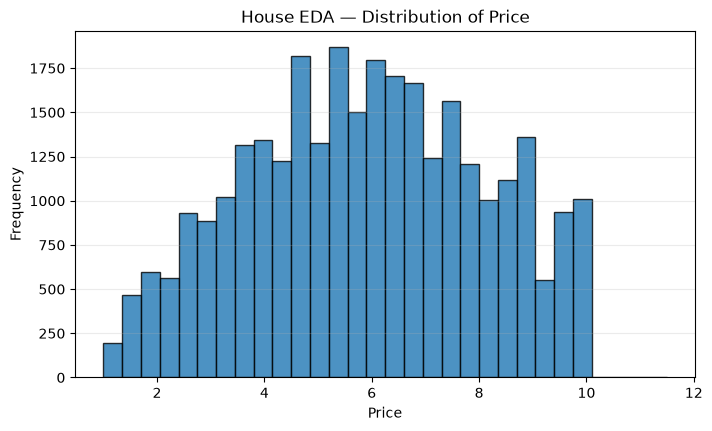

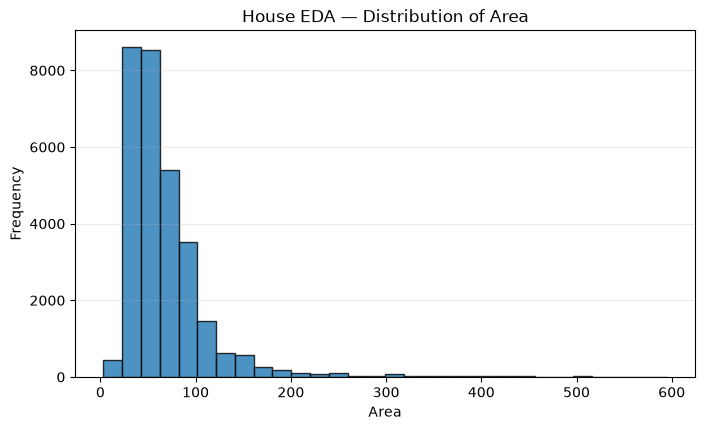

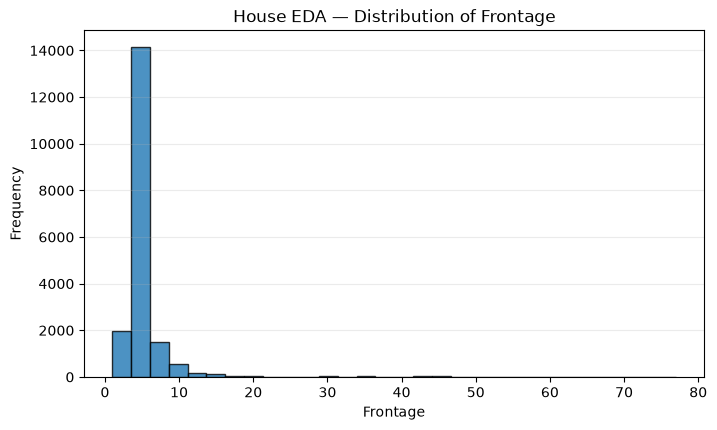

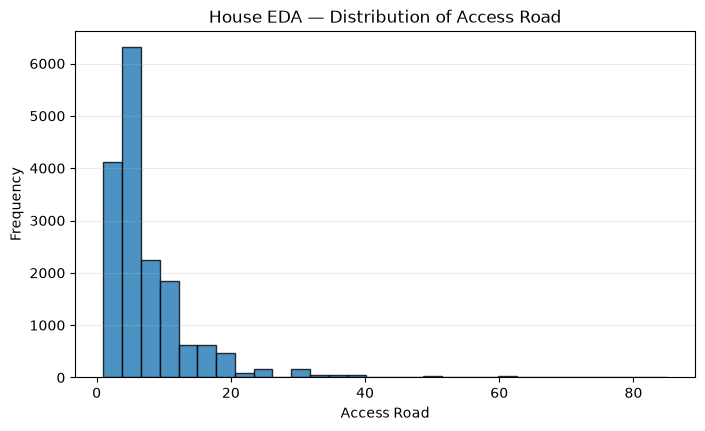

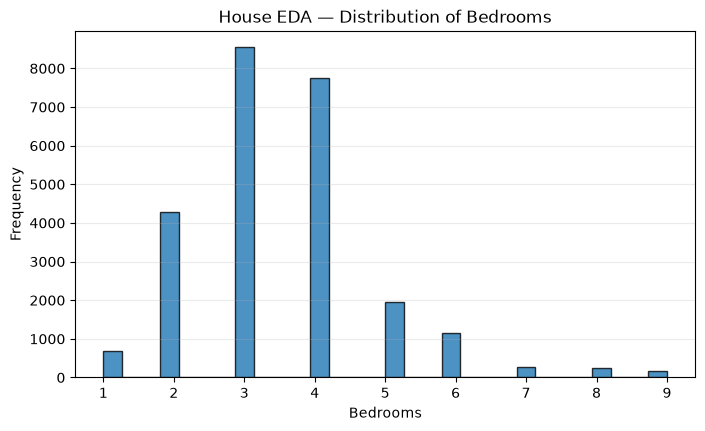

In [29]:
for col in ["Price", "Area", "Frontage", "Access Road", "Bedrooms"]:
    plot_single_distribution(
        house[col], f"House EDA — Distribution of {col}", col, bins=30
    )

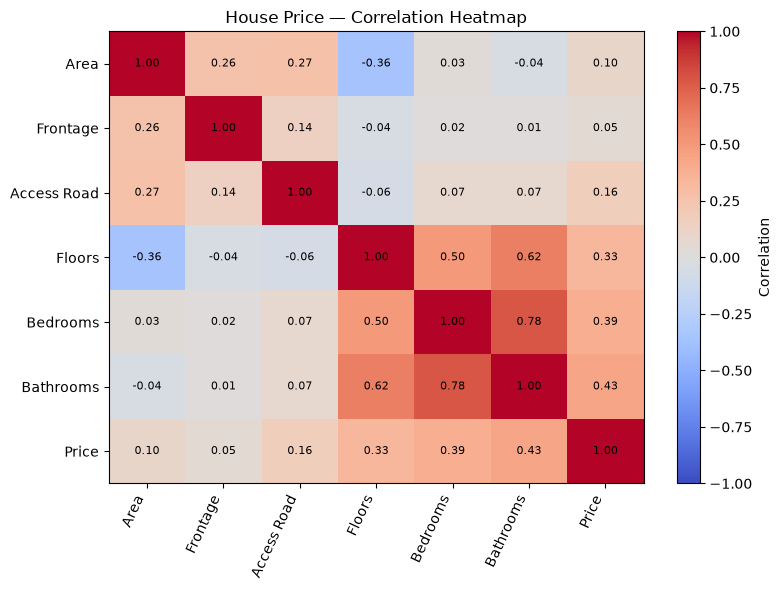

In [30]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_house, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_house.columns)), corr_house.columns, rotation=65, ha="right")
plt.yticks(range(len(corr_house.columns)), corr_house.columns)
for i in range(len(corr_house.columns)):
    for j in range(len(corr_house.columns)):
        plt.text(
            j, i, f"{corr_house.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8
        )
plt.title("House Price — Correlation Heatmap")
plt.tight_layout()
plt.show()

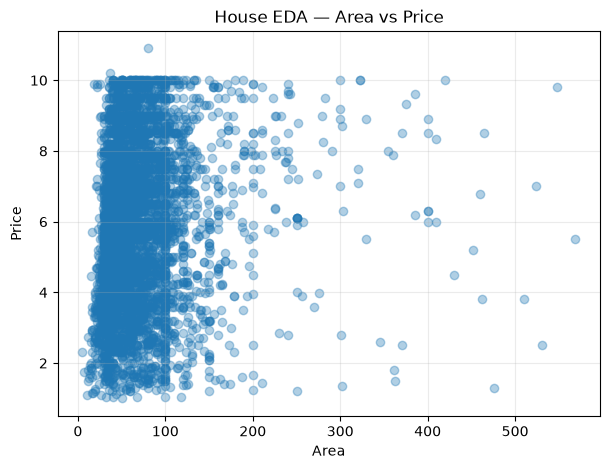

In [31]:
sc = house[["Area", "Price"]].dropna()
if len(sc) > 5000:
    sc = sc.sample(5000, random_state=SEED)
plt.figure(figsize=(7, 5))
plt.scatter(sc["Area"], sc["Price"], alpha=0.35)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House EDA — Area vs Price")
plt.grid(alpha=0.25)
plt.show()

### Interpretation of Exploratory Data Analysis

**Distribution plots.**  
`Price` trải rộng chủ yếu trong khoảng khoảng **1–10** và không tập trung vào một vùng hẹp duy nhất. Trái lại, `Area`, `Frontage` và `Access Road` đều **lệch phải rất mạnh**. Phần lớn `Area` nằm dưới khoảng 100 nhưng có một đuôi dài tới hơn 500; `Frontage` tập trung chủ yếu quanh vài mét nhưng có một số giá trị kéo tới khoảng 70–80; `Access Road` cũng tập trung ở vùng thấp nhưng xuất hiện một số observation rất lớn. `Bedrooms` là biến rời rạc, trong đó nhà **3 và 4 phòng ngủ chiếm ưu thế rõ rệt**, sau đó mới tới 2, 5 và 6 phòng.

Các long tail của `Area`, `Frontage` và `Access Road` cho thấy dataset có một số căn nhà rất khác phần lớn quan sát về kích thước hoặc điều kiện tiếp cận. Đây là những observation có thể làm bài toán hồi quy khó hơn nếu model chỉ học một quan hệ tuyến tính đơn giản.

**Correlation heatmap.**  
Trong sáu input features, `Bathrooms` có correlation với `Price` cao nhất, khoảng **0.43**, tiếp theo là `Bedrooms` **0.39** và `Floors` **0.33**. `Access Road` chỉ khoảng **0.16**, `Area` khoảng **0.10**, còn `Frontage` gần như rất yếu ở khoảng **0.05**.

Một số input features lại tương quan mạnh với nhau: `Bedrooms`–`Bathrooms` khoảng **0.78**, `Floors`–`Bathrooms` khoảng **0.62** và `Floors`–`Bedrooms` khoảng **0.50**. Điều này cho thấy các thuộc tính mô tả quy mô căn nhà có nhiều thông tin chồng lấp.

**Area vs Price scatter plot.**  
Scatter plot cho thấy quan hệ giữa `Area` và `Price` khá yếu. Ở vùng diện tích phổ biến dưới khoảng 100–150, các điểm trải gần như toàn bộ dải giá từ thấp tới cao. Ngay cả một số căn có Area rất lớn, khoảng 300–500+, giá vẫn phân tán mạnh thay vì tăng đều theo diện tích.

Điều này phù hợp với correlation `Area`–`Price` chỉ khoảng **0.10**: diện tích một mình không đủ giải thích giá nhà trong dataset. Các căn có diện tích tương tự vẫn có thể có giá rất khác nhau, cho thấy giá phụ thuộc đáng kể vào những thuộc tính khác và có thể cả các yếu tố chưa nằm trong representation hiện tại.


## 8. Train/Test Split

Dữ liệu được chia thành 80% training set và 20% held-out test set. Training set được sử dụng cho cross-validation, so sánh mô hình, phân tích hyperparameter và representation. Test set chỉ được sử dụng ở giai đoạn đánh giá final model.


In [32]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.20, random_state=SEED
)
print("Training shape:", X_train_h.shape)
print("Test shape:", X_test_h.shape)

Training shape: (24183, 6)
Test shape: (6046, 6)


## 9. Baseline

`DummyRegressor(strategy="median")` được sử dụng làm baseline. Mô hình này luôn dự đoán giá trị trung vị của target và không khai thác bất kỳ mối quan hệ nào giữa các đặc trưng với `Price`. Vì vậy, nó tạo ra một mốc tham chiếu để đánh giá mức cải thiện thực sự của các mô hình hồi quy học từ dữ liệu.


In [33]:
house_cv = KFold(n_splits=3, shuffle=True, random_state=SEED)
regression_scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
    "mape": "neg_mean_absolute_percentage_error",
}
baseline_h = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="median")),
    ]
)
s = cross_validate(
    baseline_h, X_train_h, y_train_h, cv=house_cv, scoring=regression_scoring, n_jobs=1
)
res = {
    "MAE": -s["test_mae"].mean(),
    "MSE": -s["test_mse"].mean(),
    "RMSE": -s["test_rmse"].mean(),
    "R2": s["test_r2"].mean(),
    "MAPE": -s["test_mape"].mean(),
}
display(pd.DataFrame([res], index=["DummyRegressor"]).round(4))

,MAE,MSE,RMSE,R2,MAPE
DummyRegressor,1.8437,4.8970,2.2129,-0.0001,0.4475


## 10–14. Traditional Machine-Learning Models

Năm thuật toán hồi quy được so sánh trên cùng representation sáu chiều:

| Model                       | Representation            | Learned relationship     | Learned structure        | Strength                    | Limitation                     |
| --------------------------- | ------------------------- | ------------------------ | ------------------------ | --------------------------- | ------------------------------ |
| Linear Regression           | imputed + standardized 6D | linear                   | coefficients + intercept | interpretable, fast         | limited nonlinear modeling     |
| KNN Regressor               | imputed + standardized 6D | local                    | stored training examples | nonlinear and simple        | sensitive to scale and density |
| Decision Tree Regressor     | imputed 6D                | piecewise rules          | split thresholds         | nonlinear and interpretable | overfitting risk               |
| Random Forest Regressor     | imputed 6D                | ensemble nonlinear rules | multiple trees           | robust                      | larger computational cost      |
| Gradient Boosting Regressor | imputed 6D                | additive nonlinear model | sequential boosted trees | strong tabular performance  | sensitive to hyperparameters   |

`GradientBoostingRegressor` được lựa chọn làm mô hình thứ năm thay cho RBF-SVR nhằm giữ chi phí tính toán phù hợp với tập dữ liệu trên 30.000 quan sát, trong khi vẫn bảo đảm đủ năm mô hình học máy truyền thống.


In [34]:
house_models = {
    "Linear Regression": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "KNN Regressor": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor(n_neighbors=10, weights="distance")),
        ]
    ),
    "Decision Tree Regressor": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                DecisionTreeRegressor(
                    max_depth=12, min_samples_leaf=3, random_state=SEED
                ),
            ),
        ]
    ),
    "Random Forest Regressor": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=100, min_samples_leaf=2, random_state=SEED, n_jobs=1
                ),
            ),
        ]
    ),
    "Gradient Boosting Regressor": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=120, learning_rate=0.05, max_depth=3, random_state=SEED
                ),
            ),
        ]
    ),
}
print(list(house_models))

['Linear Regression', 'KNN Regressor', 'Decision Tree Regressor', 'Random Forest Regressor', 'Gradient Boosting Regressor']


## 15. Evaluation

Bài toán hồi quy được đánh giá bằng năm độ đo: **MAE, MSE, RMSE, R² và MAPE**. MAE, MSE và RMSE đo độ lớn sai số theo các cách khác nhau; R² phản ánh tỷ lệ biến thiên của target được mô hình giải thích; MAPE biểu diễn sai số tương đối. Kết quả của năm mô hình được tính bằng 3-fold cross-validation trên training set và được trình bày bằng cả bảng số liệu lẫn biểu đồ.


In [35]:
rows = []
for name, model in house_models.items():
    s = cross_validate(
        model, X_train_h, y_train_h, cv=house_cv, scoring=regression_scoring, n_jobs=1
    )
    rows.append(
        {
            "Model": name,
            "MAE": -s["test_mae"].mean(),
            "MSE": -s["test_mse"].mean(),
            "RMSE": -s["test_rmse"].mean(),
            "R2": s["test_r2"].mean(),
            "MAPE": -s["test_mape"].mean(),
        }
    )
house_cv_results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
display(house_cv_results.round(4))

,Model,MAE,MSE,RMSE,R2,MAPE
0,Gradient Boosting Regressor,1.4829,3.3747,1.8370,0.3107,0.3419
1,Random Forest Regressor,1.4589,3.4534,1.8583,0.2947,0.3292
2,Decision Tree Regressor,1.5310,3.7955,1.9482,0.2248,0.3454
3,KNN Regressor,1.5213,3.8425,1.9602,0.2152,0.3418
4,Linear Regression,1.6260,3.9634,1.9908,0.1905,0.3771


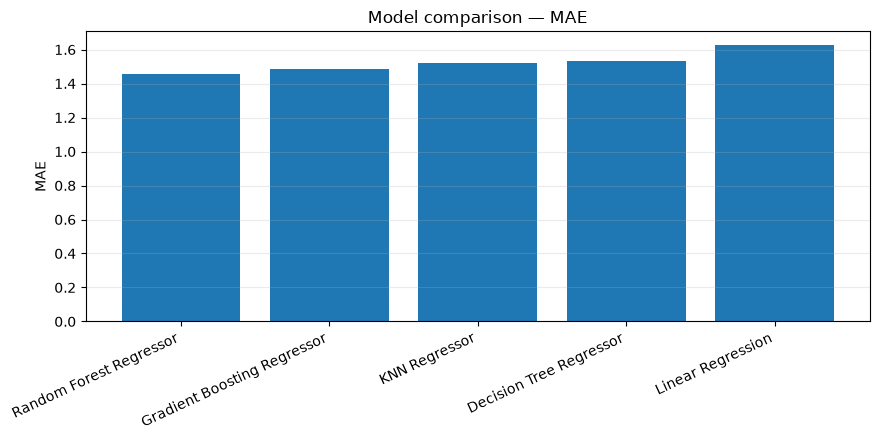

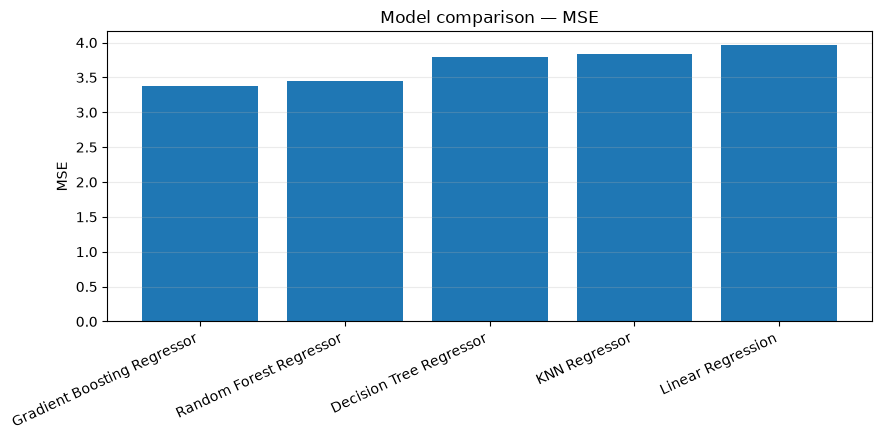

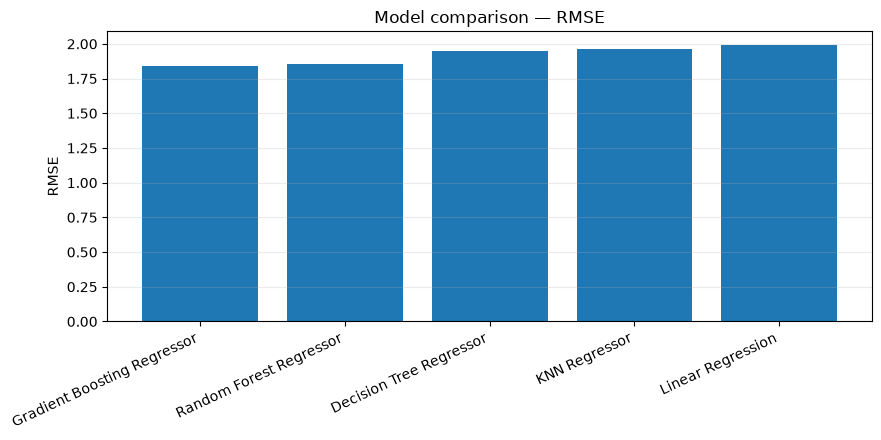

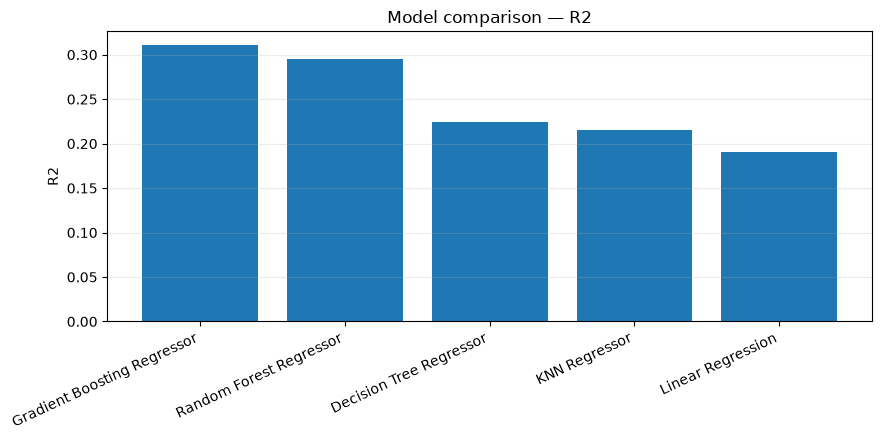

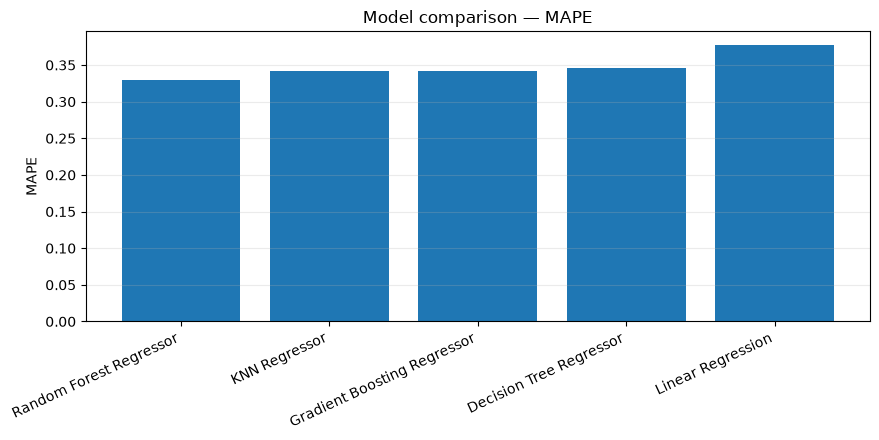

In [36]:
plot_metric_bar(house_cv_results, "MAE", False)
plot_metric_bar(house_cv_results, "MSE", False)
plot_metric_bar(house_cv_results, "RMSE", False)
plot_metric_bar(house_cv_results, "R2", True)
plot_metric_bar(house_cv_results, "MAPE", False)

### Interpretation of Regression Evaluation Plots

Không có một model thắng tuyệt đối trên cả năm metric, nhưng **Gradient Boosting Regressor có kết quả tổng thể tốt nhất theo tiêu chí chính RMSE**. Nó đạt RMSE **1.8370**, MSE **3.3747** và R² **0.3107**, đều tốt nhất trong năm model. Random Forest đứng rất gần với RMSE **1.8583** và R² **0.2947**.

Đáng chú ý, Random Forest lại có **MAE thấp nhất 1.4589** và **MAPE thấp nhất 0.3292**, nhỉnh hơn Gradient Boosting ở hai metric này. Điều đó cho thấy hai ensemble model có chất lượng khá sát nhau nhưng tối ưu các kiểu sai số hơi khác nhau. Theo rule đã xác định trước là chọn RMSE thấp nhất, Gradient Boosting vẫn là lựa chọn cuối cùng.

Decision Tree và KNN tạo nhóm trung bình với RMSE lần lượt **1.9482** và **1.9602**, còn Linear Regression kém nhất với RMSE **1.9908**, R² chỉ **0.1905** và MAPE **0.3771**. Việc hai ensemble nonlinear đứng đầu trong khi Linear Regression đứng cuối gợi ý rằng quan hệ giữa sáu house features và `Price` không được mô tả tốt chỉ bằng một quan hệ tuyến tính đơn giản.

Tuy nhiên ngay cả model tốt nhất cũng chỉ có R² khoảng **0.31**. Nghĩa là representation hiện tại mới giải thích được một phần tương đối hạn chế biến thiên của `Price`; khoảng cách hiệu năng giữa các thuật toán nhỏ hơn khá nhiều so với phần biến thiên mà toàn bộ model vẫn chưa giải thích được.


## 16. Experiment 1 — Model Comparison

Thí nghiệm thứ nhất so sánh năm thuật toán dưới cùng một representation sáu đặc trưng và cùng 3-fold cross-validation. Câu hỏi nghiên cứu là: **mô hình nào đạt RMSE trung bình thấp nhất khi các điều kiện dữ liệu và quy trình đánh giá được giữ cố định?**


In [37]:
best_house_model_name = house_cv_results.iloc[0]["Model"]
best_house_cv_rmse = float(house_cv_results.iloc[0]["RMSE"])
print("Best model by mean CV RMSE:", best_house_model_name)
print("Mean CV RMSE:", round(best_house_cv_rmse, 4))

Best model by mean CV RMSE: Gradient Boosting Regressor
Mean CV RMSE: 1.837


## 17. Experiment 2 — Hyperparameter Investigation

Thí nghiệm thứ hai khảo sát ảnh hưởng của `n_estimators` đối với Random Forest Regressor. Các giá trị 30, 60 và 100 được kiểm tra trong khi representation, imputation, random seed và cross-validation protocol được giữ nguyên. RMSE trung bình được sử dụng để đánh giá sự thay đổi hiệu năng khi số lượng cây tăng lên.


,n_estimators,Mean CV RMSE
0,30,1.8675
1,60,1.8605
2,100,1.8583


Best n_estimators: 100


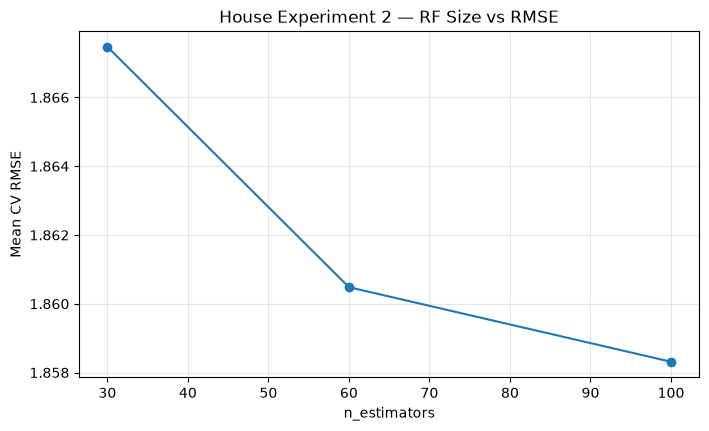

In [38]:
vals = [30, 60, 100]
scores = []
for n in vals:
    p = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=n, min_samples_leaf=2, random_state=SEED, n_jobs=1
                ),
            ),
        ]
    )
    s = cross_val_score(
        p,
        X_train_h,
        y_train_h,
        cv=house_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
    )
    scores.append(-s.mean())
rf_experiment = pd.DataFrame({"n_estimators": vals, "Mean CV RMSE": scores})
display(rf_experiment.round(4))
best_n_trees = int(
    rf_experiment.loc[rf_experiment["Mean CV RMSE"].idxmin(), "n_estimators"]
)
print("Best n_estimators:", best_n_trees)
plt.figure(figsize=(8, 4.5))
plt.plot(vals, scores, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Mean CV RMSE")
plt.title("House Experiment 2 — RF Size vs RMSE")
plt.grid(alpha=0.3)
plt.show()

### Interpretation of Random Forest Hyperparameter Plot

Khi tăng số cây từ **30 → 60 → 100**, mean CV RMSE giảm lần lượt từ **1.8675 → 1.8605 → 1.8583**. Như vậy tăng `n_estimators` có cải thiện kết quả, nhưng mức cải thiện ngày càng nhỏ: bước 30→60 giảm khoảng **0.0070 RMSE**, còn bước 60→100 chỉ giảm thêm khoảng **0.0022**.

Đường biểu diễn vì vậy đang có xu hướng **phẳng dần**, cho thấy Random Forest bắt đầu đạt vùng diminishing returns: thêm nhiều cây tiếp tục giúp một chút nhưng không tạo ra thay đổi lớn về prediction error.

`n_estimators=100` là cấu hình tốt nhất trong ba giá trị đã thử, nhưng chênh lệch tổng cộng so với 30 cây chỉ khoảng **0.0092 RMSE**. Điều này cho thấy trong bài toán này, chỉ tăng kích thước forest không phải yếu tố có khả năng tạo ra bước cải thiện lớn; representation và các hyperparameter khác có thể quan trọng hơn.


## 18. Experiment 3 — Representation / Feature Investigation

Ảnh hưởng của representation được kiểm tra bằng cách so sánh:

\[
X_3=[Area,Floors,Bedrooms]
\]

với

\[
X_6=[Area,Frontage,AccessRoad,Floors,Bedrooms,Bathrooms]
\]

Cả hai representation sử dụng cùng Gradient Boosting pipeline, cùng imputation và cùng cross-validation protocol. Do thuật toán được giữ cố định, khác biệt về RMSE và R² cho thấy tác động của thông tin bổ sung trong vector sáu chiều.


,Representation,RMSE,R2
0,3 features,1.8901,0.2703
1,6 features,1.8420,0.3070


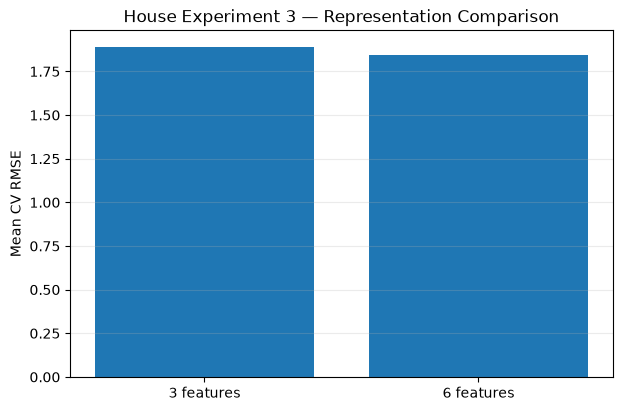

In [39]:
rep_model_h = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=100, learning_rate=0.05, max_depth=3, random_state=SEED
            ),
        ),
    ]
)
rows = []
for label, fs in {
    "3 features": ["Area", "Floors", "Bedrooms"],
    "6 features": HOUSE_FEATURES,
}.items():
    Xrep = house.loc[X_train_h.index, fs]
    s = cross_validate(
        rep_model_h,
        Xrep,
        y_train_h,
        cv=house_cv,
        scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
        n_jobs=1,
    )
    rows.append(
        {
            "Representation": label,
            "RMSE": -s["test_rmse"].mean(),
            "R2": s["test_r2"].mean(),
        }
    )
house_representation_results = pd.DataFrame(rows)
display(house_representation_results.round(4))
plt.figure(figsize=(7, 4.5))
plt.bar(
    house_representation_results["Representation"], house_representation_results["RMSE"]
)
plt.ylabel("Mean CV RMSE")
plt.title("House Experiment 3 — Representation Comparison")
plt.grid(axis="y", alpha=0.25)
plt.show()

### Interpretation of Representation Comparison

Với representation chỉ gồm `Area`, `Floors` và `Bedrooms`, Gradient Boosting đạt mean CV RMSE **1.8901** và R² **0.2703**. Khi thêm `Frontage`, `Access Road` và `Bathrooms` để tạo representation sáu chiều, RMSE giảm xuống **1.8420** và R² tăng lên **0.3070**.

Như vậy sáu features tạo cải thiện **nhất quán ở cả hai hướng**: error giảm khoảng **0.0481 RMSE**, đồng thời phần biến thiên target được giải thích tăng khoảng **0.0367 R²**. Đây là mức cải thiện rõ hơn so với experiment representation của Diabetes, dù vẫn chưa phải một bước nhảy lớn.

Kết quả cũng phù hợp với EDA: trong ba feature được thêm, `Bathrooms` có correlation với `Price` khoảng **0.43**, cao nhất trong toàn bộ sáu input features, còn `Access Road` cũng đóng góp một signal nhỏ khoảng **0.16**. Vì vậy việc bỏ các feature này làm representation ba chiều mất một phần thông tin dự đoán hữu ích.

Dù representation sáu chiều tốt hơn, R² vẫn chỉ khoảng **0.31**, cho thấy sáu thuộc tính hiện tại vẫn chưa mô tả đầy đủ các yếu tố quyết định giá nhà.


## 19. Final Model

Mô hình cuối cùng được chọn theo RMSE trung bình thấp nhất trên cross-validation của training set. Pipeline tương ứng được huấn luyện lại trên toàn bộ training set và đánh giá duy nhất trên held-out test set bằng MAE, MSE, RMSE, R² và MAPE. Hai trực quan hóa `Actual vs Predicted` và residual plot được sử dụng để phân tích thêm chất lượng dự đoán và cấu trúc sai số.


In [40]:
final_house_model = clone(house_models[best_house_model_name])
final_house_model.fit(X_train_h, y_train_h)
y_pred_h = final_house_model.predict(X_test_h)
final_house_metrics = regression_metrics(y_test_h, y_pred_h)
print("Final house model:", best_house_model_name)
display(pd.DataFrame([final_house_metrics], index=["Held-out test"]).round(4))

Final house model: Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,MAPE
Held-out test,1.5023,3.4569,1.8593,0.2910,0.3478


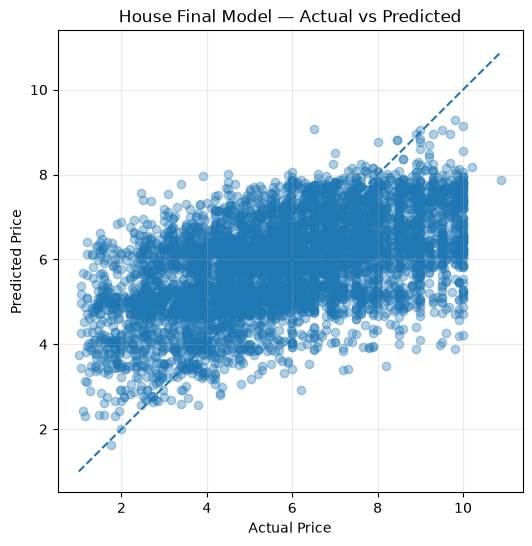

In [41]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_h, y_pred_h, alpha=0.35)
lo = min(float(y_test_h.min()), float(y_pred_h.min()))
hi = max(float(y_test_h.max()), float(y_pred_h.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Final Model — Actual vs Predicted")
plt.grid(alpha=0.25)
plt.show()

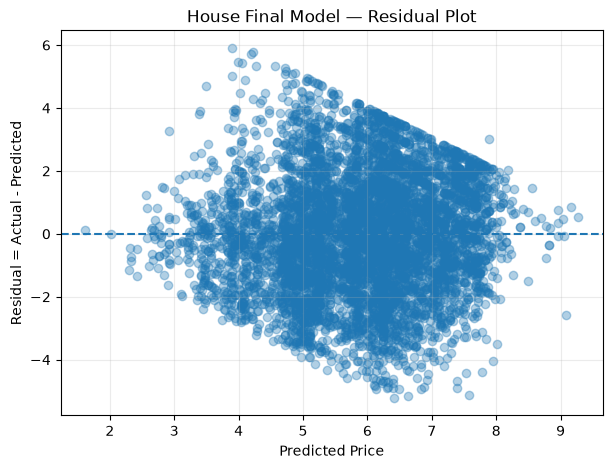

In [42]:
residuals = y_test_h.to_numpy() - y_pred_h
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_h, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual = Actual - Predicted")
plt.title("House Final Model — Residual Plot")
plt.grid(alpha=0.25)
plt.show()

### Interpretation of Final Regression Plots

**Actual vs Predicted.**  
Các điểm có xu hướng tăng theo đường chéo, cho thấy Gradient Boosting đã học được một phần quan hệ giữa sáu thuộc tính đầu vào và `Price`. Tuy nhiên prediction bị **co mạnh về vùng trung tâm**: trong khi Actual Price trải khoảng từ gần 1 tới trên 10, phần lớn Predicted Price chỉ nằm khoảng **3–8**.

Ở các căn có Actual Price thấp, đặc biệt vùng khoảng **1–3**, rất nhiều điểm nằm phía trên đường `y=x`, nghĩa là model thường **dự đoán cao hơn giá thực tế**. Ngược lại, ở vùng Actual Price cao khoảng **8–10+**, phần lớn điểm nằm phía dưới đường lý tưởng, cho thấy model thường **dự đoán thấp hơn giá thực tế**. Model vì vậy bám dữ liệu tốt hơn ở vùng giá trung bình nhưng gặp khó khăn ở hai đầu của phân bố.

Pattern này phù hợp với held-out R² chỉ **0.2910** và RMSE **1.8593**: model có predictive signal nhưng chưa tái tạo được đầy đủ độ biến thiên của giá.

**Residual Plot.**  
Residual không tạo thành một đám mây ngẫu nhiên có độ rộng gần như đồng đều quanh đường 0. Các điểm tạo thành một vùng có cấu trúc khá rõ, với residual trải xấp xỉ từ **-5 đến +6**. Ở nhiều prediction cao khoảng **7–8**, residual nằm về phía âm khá nhiều, tương ứng với các trường hợp model dự đoán cao hơn thực tế. Trong khi đó ở vùng prediction trung bình khoảng **4–6**, vẫn xuất hiện nhiều residual dương lớn, tức có những căn nhà mà model đánh giá thấp đáng kể.

Hai biểu đồ kể cùng một câu chuyện: model có xu hướng **kéo prediction về mức giá trung bình**, làm sai số có pattern thay vì hoàn toàn ngẫu nhiên. Điều này cho thấy giới hạn không chỉ nằm ở việc chọn regressor mà còn ở representation: sáu thuộc tính `Area`, `Frontage`, `Access Road`, `Floors`, `Bedrooms` và `Bathrooms` chưa đủ để phân biệt tốt các căn nhà có giá cực thấp hoặc cực cao. Các yếu tố chưa có trong representation, chẳng hạn vị trí hoặc những đặc điểm khác của bất động sản, có thể là nguồn thông tin còn thiếu; đây là một suy luận từ pattern của residual chứ không phải kết luận nhân quả trực tiếp từ biểu đồ.


In [ ]:
HOUSE_MODEL_PATH = ARTIFACT_DIR / "house_pipeline.joblib"
HOUSE_MODELS_DIR = ARTIFACT_DIR / "house_models"
HOUSE_MODELS_DIR.mkdir(exist_ok=True)

HOUSE_MODEL_SLUGS = {
    "Linear Regression": "linear_regression",
    "KNN Regressor": "knn_regressor",
    "Decision Tree Regressor": "decision_tree_regressor",
    "Random Forest Regressor": "random_forest_regressor",
    "Gradient Boosting Regressor": "gradient_boosting_regressor",
}

# Preserve the existing artifact as the recommended/final model.
joblib.dump(final_house_model, HOUSE_MODEL_PATH)

# Fit one deployable pipeline for each of the five evaluated algorithms.
# The recommended model reuses final_house_model so its artifact is
# exactly the same trained pipeline used for the held-out test evaluation.
house_deployment_models = {}
for model_name, model_template in house_models.items():
    if model_name == best_house_model_name:
        fitted_model = final_house_model
    else:
        fitted_model = clone(model_template)
        fitted_model.fit(X_train_h, y_train_h)

    model_id = HOUSE_MODEL_SLUGS[model_name]
    model_path = HOUSE_MODELS_DIR / f"{model_id}.joblib"
    joblib.dump(fitted_model, model_path)

    house_deployment_models[model_id] = {
        "name": model_name,
        "artifact": str(Path("house_models") / f"{model_id}.joblib"),
        "recommended": model_name == best_house_model_name,
    }

recommended_house_model_id = HOUSE_MODEL_SLUGS[best_house_model_name]

meta = {
    "task": "regression",
    "features": HOUSE_FEATURES,
    "target": HOUSE_TARGET,
    "selected_model": best_house_model_name,
    "recommended_model_id": recommended_house_model_id,
    "selection_metric": "mean_cv_rmse",
    "available_models": house_deployment_models,
    "test_metrics": {k: float(v) for k, v in final_house_metrics.items()},
    "price_unit_note": "Prediction is in the same unit as dataset Price.",
}
(ARTIFACT_DIR / "house_metadata.json").write_text(
    json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("Saved recommended house model:", HOUSE_MODEL_PATH)
print("Saved selectable house models:")
for model_id, info in house_deployment_models.items():
    marker = " <- recommended" if info["recommended"] else ""
    print(f"  {model_id}: {info['artifact']}{marker}")

Saved recommended house model: artifacts\house_pipeline.joblib
Saved selectable house models:
  linear_regression: house_models\linear_regression.joblib
  knn_regressor: house_models\knn_regressor.joblib
  decision_tree_regressor: house_models\decision_tree_regressor.joblib
  random_forest_regressor: house_models\random_forest_regressor.joblib
  gradient_boosting_regressor: house_models\gradient_boosting_regressor.joblib <- recommended


## 20. Knowledge Graph — House Price

Knowledge Graph của miền bất động sản biểu diễn các thực thể `House`, `Feature`, `Prediction`, `MLModel` và `TargetConcept`. Các cạnh mô tả quan hệ giữa căn nhà với thuộc tính, giữa căn nhà với prediction và giữa prediction với model/price concept.

Khác với feature vector dùng cho regression, graph representation làm rõ quan hệ ngữ nghĩa giữa các thực thể. Script Cypher được sinh ra để đồ thị có thể được lưu và truy vấn trong Neo4j.


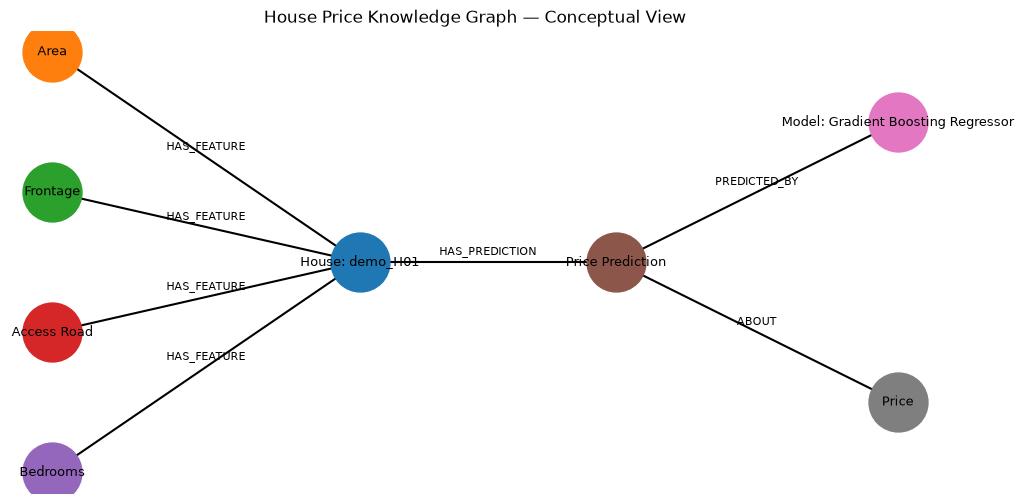

In [44]:
nodes = {
    "house": "House: demo_H01",
    "area": "Area",
    "frontage": "Frontage",
    "road": "Access Road",
    "bedrooms": "Bedrooms",
    "pred": "Price Prediction",
    "model": f"Model: {best_house_model_name}",
    "target": "Price",
}
edges = [
    ("house", "HAS_FEATURE", "area"),
    ("house", "HAS_FEATURE", "frontage"),
    ("house", "HAS_FEATURE", "road"),
    ("house", "HAS_FEATURE", "bedrooms"),
    ("house", "HAS_PREDICTION", "pred"),
    ("pred", "PREDICTED_BY", "model"),
    ("pred", "ABOUT", "target"),
]
pos = {
    "house": (0, 0),
    "area": (-2.4, 1.5),
    "frontage": (-2.4, 0.5),
    "road": (-2.4, -0.5),
    "bedrooms": (-2.4, -1.5),
    "pred": (2, 0),
    "model": (4.2, 1),
    "target": (4.2, -1),
}
draw_simple_kg(nodes, edges, pos, "House Price Knowledge Graph — Conceptual View")

In [45]:
house_cypher = f"""
MERGE (h:House {{id:'demo_H01'}})
MERGE (a:Feature {{name:'Area'}})
MERGE (f:Feature {{name:'Frontage'}})
MERGE (r:Feature {{name:'Access Road'}})
MERGE (b:Feature {{name:'Bedrooms'}})
MERGE (t:TargetConcept {{name:'Price'}})
MERGE (m:MLModel {{name:'{best_house_model_name}'}})
MERGE (p:Prediction {{task:'Vietnam House Price Regression'}})
MERGE (h)-[:HAS_FEATURE]->(a)
MERGE (h)-[:HAS_FEATURE]->(f)
MERGE (h)-[:HAS_FEATURE]->(r)
MERGE (h)-[:HAS_FEATURE]->(b)
MERGE (h)-[:HAS_PREDICTION]->(p)
MERGE (p)-[:PREDICTED_BY]->(m)
MERGE (p)-[:ABOUT]->(t);
""".strip()

path = NEO4J_DIR / "house_knowledge_graph.cypher"
path.write_text(house_cypher, encoding="utf-8")
print(house_cypher)
print()
print("Saved:", path)
optional_run_neo4j(house_cypher)

MERGE (h:House {id:'demo_H01'})
MERGE (a:Feature {name:'Area'})
MERGE (f:Feature {name:'Frontage'})
MERGE (r:Feature {name:'Access Road'})
MERGE (b:Feature {name:'Bedrooms'})
MERGE (t:TargetConcept {name:'Price'})
MERGE (m:MLModel {name:'Gradient Boosting Regressor'})
MERGE (p:Prediction {task:'Vietnam House Price Regression'})
MERGE (h)-[:HAS_FEATURE]->(a)
MERGE (h)-[:HAS_FEATURE]->(f)
MERGE (h)-[:HAS_FEATURE]->(r)
MERGE (h)-[:HAS_FEATURE]->(b)
MERGE (h)-[:HAS_PREDICTION]->(p)
MERGE (p)-[:PREDICTED_BY]->(m)
MERGE (p)-[:ABOUT]->(t);

Saved: neo4j_scripts\house_knowledge_graph.cypher
Knowledge Graph uploaded to Neo4j.


## 21. Application

Ứng dụng dự đoán giá nhà sử dụng sáu trường `Area`, `Frontage`, `Access Road`, `Floors`, `Bedrooms` và `Bathrooms`. Cả Web Application và Android Mobile Application gửi sáu giá trị này tới cùng Flask REST API, đồng thời người dùng có thể chọn một trong năm regressors đã được đánh giá trong notebook.

Backend chuyển dữ liệu thành một `DataFrame` có schema và thứ tự cột trùng với training representation rồi truyền qua trained pipeline tương ứng với model được chọn. Notebook vẫn lưu `house_pipeline.joblib` như artifact của final/recommended model, đồng thời lưu thêm năm selectable pipelines trong `artifacts/house_models/`. Vì preprocessing và estimator được lưu chung trong từng pipeline, bước inference trên Web và Mobile sử dụng đúng logic đã được sử dụng khi huấn luyện.

API trả về giá dự đoán của model được chọn theo cùng đơn vị với cột `Price` của dataset.


## 22. System Demonstration

Ba trường hợp nhà với quy mô và đặc điểm khác nhau được đưa qua toàn bộ hệ thống:

`Input → Feature Representation → Preprocessing → Regression Model → Predicted Price`

Các kết quả minh họa khả năng áp dụng mô hình cho các observation mới có cùng representation.


In [46]:
house_demo_cases = pd.DataFrame(
    [
        {
            "Area": 40,
            "Frontage": 4.0,
            "Access Road": 3.0,
            "Floors": 2,
            "Bedrooms": 2,
            "Bathrooms": 2,
        },
        {
            "Area": 70,
            "Frontage": 5.0,
            "Access Road": 6.0,
            "Floors": 4,
            "Bedrooms": 4,
            "Bathrooms": 3,
        },
        {
            "Area": 120,
            "Frontage": 7.0,
            "Access Road": 12.0,
            "Floors": 5,
            "Bedrooms": 5,
            "Bathrooms": 5,
        },
    ]
)[HOUSE_FEATURES]
r = house_demo_cases.copy()
r["Predicted Price"] = final_house_model.predict(house_demo_cases)
display(r.round(4))

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Predicted Price
0,40,4.0000,3.0000,2,2,2,3.3735
1,70,5.0000,6.0000,4,4,3,7.0186
2,120,7.0000,12.0000,5,5,5,8.1966


## 23. Reflection — House Price

Hệ thống nhận sáu thuộc tính số của một căn nhà và biểu diễn chúng bằng vector sáu chiều. Mô hình học từ các cặp `(x, Price)` trong dữ liệu huấn luyện để xấp xỉ quan hệ giữa representation này và giá nhà, sau đó áp dụng hàm đã học cho observation chưa từng xuất hiện. Khả năng học quan hệ từ nhiều ví dụ và tổng quát hóa sang input mới là thành phần “intelligent” trong phạm vi bài toán.

Representation hiện tại có ưu điểm là đơn giản và thuận lợi cho triển khai, nhưng chỉ bảo toàn một phần thông tin của thị trường bất động sản. Những yếu tố như vị trí, khu vực, tình trạng pháp lý, nội thất, hướng nhà và biến động theo thời gian không được mô hình chính sử dụng. Cùng bài toán có thể được biểu diễn bằng graph, sequence, image hoặc learned embedding nếu có thêm dữ liệu tương ứng.

Xét trong lịch sử phát triển AI, hệ thống thuộc giai đoạn:

`Structured Data → Human-designed Features → Traditional ML Regression → Prediction`.


## 24. Conclusion — House Price

Case Study B đã xây dựng một hệ thống hồi quy hoàn chỉnh từ dữ liệu bất động sản thực đến ứng dụng dự đoán. Năm mô hình được so sánh bằng năm độ đo, ba thí nghiệm có kiểm soát được sử dụng để phân tích thuật toán, hyperparameter và representation, còn final model được đánh giá trên held-out test set. Các biểu đồ Actual-vs-Predicted và residual hỗ trợ phân tích sai số. Mô hình cuối cùng được lưu dưới dạng pipeline và được sử dụng chung bởi Web Application và Android Mobile Application thông qua Flask REST API; representation dạng vector đồng thời được bổ sung bằng Knowledge Graph tương thích Neo4j.


# PART C — WEB AND MOBILE APPLICATION DEPLOYMENT

## 1. Deployment Architecture

Mỗi case study có năm trained pipelines tương ứng với năm thuật toán đã được đánh giá trong notebook. Flask backend cung cấp REST API cho hai client độc lập: Web Application và Android Mobile Application. Người dùng chọn model trên client; backend dùng model identifier để nạp/chọn đúng trained pipeline và thực hiện inference.

`diabetes_pipeline.joblib` và `house_pipeline.joblib` vẫn được giữ như aliases của final/recommended models, trong khi các model còn lại được lưu trong các thư mục model-specific.

```text
                         ┌──────────────────────────┐
                         │ Flask Backend / REST API │
                         │                          │
Web Application ────────►│ POST /api/diabetes      │
                         │ POST /api/house          │
Android Mobile App ─────►│ GET  /health             │
                         └────────────┬─────────────┘
                                      │
                         model id + six input features
                                      │
                         ┌────────────┴─────────────┐
                         │                          │
              5 Diabetes pipelines        5 House pipelines
                         │                          │
                         ▼                          ▼
              Class + Probability          Predicted Price
```

Web và Mobile không huấn luyện model và không chứa prediction implementation riêng. Cả hai sử dụng cùng backend và cùng trained model artifacts; cùng một input và cùng một model selection phải tạo cùng prediction trên hai clients.


## 2. Separation Between Notebook and Deployment Source

Notebook chịu trách nhiệm cho:

1. dataset loading và preprocessing;
2. exploratory data analysis;
3. model training và experiments;
4. model evaluation;
5. final model selection;
6. serialization của trained pipelines.

Notebook giữ nguyên hai final/recommended model artifacts và hai metadata files hiện có, đồng thời bổ sung năm selectable model artifacts cho mỗi case study:

```text
artifacts/
├── diabetes_pipeline.joblib
├── diabetes_metadata.json
├── diabetes_models/
│   ├── logistic_regression.joblib
│   ├── knn.joblib
│   ├── decision_tree.joblib
│   ├── random_forest.joblib
│   └── svm_rbf.joblib
├── house_pipeline.joblib
├── house_metadata.json
└── house_models/
    ├── linear_regression.joblib
    ├── knn_regressor.joblib
    ├── decision_tree_regressor.joblib
    ├── random_forest_regressor.joblib
    └── gradient_boosting_regressor.joblib
```

Hai metadata files chứa `available_models`, stable model IDs, artifact paths và `recommended_model_id`, để application có thể xây dựng model selector mà không cần hard-code prediction logic.

Application source code vẫn được tách khỏi notebook. Việc tách source code giúp notebook tập trung vào quá trình phát triển intelligent system, trong khi Web và Mobile có thể được phát triển, kiểm thử và deploy độc lập.


## 3. REST API Contract

### Health Check

```text
GET /health
```

Response:

```json
{
  "status": "ok"
}
```

### Diabetes Prediction

```text
POST /api/diabetes
```

Input gồm một `model` identifier và đúng sáu features:

```json
{
  "model": "logistic_regression",
  "Glucose": 120,
  "BMI": 25.5,
  "Age": 35,
  "Pregnancies": 2,
  "BloodPressure": 75,
  "DiabetesPedigreeFunction": 0.45
}
```

Các model IDs hợp lệ được lấy từ `diabetes_metadata.json`:

```text
logistic_regression
knn
decision_tree
random_forest
svm_rbf
```

Backend tạo `DataFrame` theo đúng schema của training representation, chọn trained pipeline tương ứng với `model`, rồi trả predicted class và positive-class probability.

### House Price Prediction

```text
POST /api/house
```

Input gồm một `model` identifier và sáu features:

```json
{
  "model": "gradient_boosting_regressor",
  "Area": 60,
  "Frontage": 5,
  "Access Road": 4,
  "Floors": 3,
  "Bedrooms": 3,
  "Bathrooms": 2
}
```

Các model IDs hợp lệ được lấy từ `house_metadata.json`:

```text
linear_regression
knn_regressor
decision_tree_regressor
random_forest_regressor
gradient_boosting_regressor
```

Backend chọn trained pipeline tương ứng với `model` và trả về predicted `Price` theo cùng đơn vị được sử dụng trong dataset.

Web Application và Android Mobile Application sử dụng cùng model IDs và cùng hai prediction endpoints.


## 4. Web Application

Web Application cung cấp hai chức năng trong cùng một giao diện:

1. Diabetes Prediction;
2. Vietnam House Price Prediction.

Mỗi chức năng có sáu trường input tương ứng với representation của bài toán và thêm một model selector chứa năm thuật toán đã được đánh giá trong notebook. Final model được đánh dấu là recommended/default selection, nhưng người dùng có thể chọn model khác để quan sát sự khác biệt về prediction.

Web client gửi model identifier cùng sáu input values tới Flask REST API và hiển thị response trả về.

Đối với Diabetes Prediction, giao diện hiển thị predicted class và probability của model được chọn nhưng đồng thời ghi rõ rằng đây là kết quả của mô hình học máy phục vụ mục đích học tập, không phải chẩn đoán y khoa.

Web Application được thiết kế responsive nhưng responsive design chỉ là đặc tính của Web; Android Mobile Application vẫn được triển khai như một application riêng.


## 5. Android Mobile Application

Mobile Application được xây dựng riêng bằng React Native + Expo.

Ứng dụng cung cấp cùng hai chức năng:

- Diabetes Prediction;
- Vietnam House Price Prediction.

Mỗi màn hình prediction có model selector với cùng năm lựa chọn và cùng stable model IDs như Web Application. Final model được dùng làm recommended/default selection, nhưng người dùng có thể chọn một model khác trước khi gửi request.

Mobile Application không chứa scikit-learn model. Sau khi người dùng chọn model và nhập dữ liệu, ứng dụng gửi model identifier cùng input values tới Flask REST API và hiển thị JSON response trả về.

Do Web và Mobile dùng chung backend và cùng trained artifacts, cùng một input với cùng model selection phải nhận cùng prediction trên hai clients.


## 6. Deployment

### Web and REST API

Flask Web Application và REST API được deploy lên Render bằng Python WSGI server `gunicorn`.

```text
Build command:
pip install -r requirements.txt

Start command:
gunicorn app:app
```

### Android

Android Application được build thành file `.apk` bằng Expo EAS Build với internal distribution. APK có thể được cài trực tiếp lên thiết bị Android mà không cần đưa ứng dụng lên Google Play Store.

Kiến trúc deployment cuối cùng:

```text
Internet
   │
   ├── Public Web URL ──────────────┐
   │                                ▼
   │                         Flask / Render
   │                                ▲
   └── Android APK ── HTTPS API ────┘
```


## 7. Deployment Verification

Trước khi nộp, cả hai clients phải được kiểm thử với cùng các demo inputs được sử dụng trong Part A và Part B.

Các bước verification:

1. `GET /health` trả về HTTP 200.
2. Web Diabetes form nhận input và trả prediction.
3. Web House form nhận input và trả predicted price.
4. Android Diabetes form gọi public API thành công.
5. Android House form gọi public API thành công.
6. Cùng một input trên Web và Mobile phải trả cùng prediction.
7. Prediction từ REST API phải trùng với prediction khi gọi trực tiếp trained pipeline.

### Public Deployment Links

- **Web Application:** `ADD_RENDER_URL_HERE`
- **REST API Health Check:** `ADD_RENDER_URL_HERE/health`
- **Android APK / Internal Distribution:** `ADD_ANDROID_DOWNLOAD_URL_HERE`
- **Source Code Repository:** `ADD_GITHUB_URL_HERE`

Các URL trên phải được cập nhật bằng địa chỉ triển khai thực tế trước khi nộp Assignment 01.


# FINAL REFLECTION

Hai case study cho thấy một trained model chỉ là một thành phần của intelligent system. Hệ thống hoàn chỉnh bao gồm chuỗi xử lý:

`Environment/User → Input → Representation → Preprocessing → Learning Model → Prediction → Application`

Trong cả hai bài toán, khả năng học từ dữ liệu huấn luyện và tổng quát hóa sang observation mới tạo nên năng lực dự đoán của hệ thống. Tuy nhiên, mức độ “thông minh” vẫn bị giới hạn bởi representation được thiết kế thủ công và phạm vi thông tin có trong dataset.

Knowledge Graph minh họa một góc nhìn biểu diễn khác. Feature vector thích hợp cho các thuật toán học máy truyền thống trên dữ liệu bảng, trong khi graph representation biểu diễn rõ quan hệ ngữ nghĩa giữa các thực thể. Sự khác biệt này cho thấy lựa chọn representation quyết định loại thông tin mà hệ thống có thể sử dụng và mở đường cho các phương pháp phát triển hệ thống thông minh phức tạp hơn.


# FINAL CONCLUSION

Bài thực hành đã xây dựng hai intelligent systems theo cùng một quy trình phát triển nhưng cho hai loại bài toán khác nhau: classification và regression. Case Study A sử dụng sáu đặc trưng sức khỏe để dự đoán `Outcome`; Case Study B sử dụng sáu thuộc tính bất động sản để dự đoán `Price`. Mỗi hệ thống có baseline, năm mô hình truyền thống, ba controlled experiments, evaluation bằng nhiều độ đo và một final pipeline được lựa chọn dựa trên cross-validation rồi đánh giá trên held-out test set.

Ngoài phần học máy, hai hệ thống còn được mở rộng thành một application layer thống nhất. Hai trained pipelines được phục vụ bởi Flask REST API; Web Application và Android Mobile Application là hai client độc lập sử dụng cùng backend và cùng model artifacts. Mỗi miền dữ liệu đồng thời có một Knowledge Graph và Neo4j Cypher representation. Nhờ đó, sản phẩm cuối bao quát đầy đủ chuỗi `Input → Representation → Learning → Prediction → Application → Deployment` của một intelligent system ở mức Assignment 01.
